# Lab 05: RNNs vs. Transformers vs. Vision Transformers
## ITAI 2376 — Deep Learning | Spring 2026
### Houston City College — AI & Robotics Program

---

**Welcome to Lab 05!** This is a comprehensive, hands-on lab where you will build, train, and compare three major deep learning architectures:

| Part | Architecture | Task | Dataset |
|------|-------------|------|---------|
| **A** | LSTM & GRU (RNNs) | News Topic Classification | AG News |
| **B** | DistilBERT (Transformer) | News Topic Classification | AG News (same data!) |
| **C** | Vision Transformer (ViT) | Image Classification | CIFAR-10 |
| **D** | — | Comparative Analysis & Reflection | All results |

**Why this lab matters:** By using the *same text dataset* for both RNNs and Transformers, you get a direct, apples-to-apples comparison. Then, by exploring Vision Transformers, you see how the Transformer idea extends beyond text into images — and you can compare ViT performance to the CNNs you built in Module 03.

**Estimated Time:** 3–4 hours  
**Environment:** Google Colab (free tier is sufficient)

---

⚠️ **Important:** Run cells in order. If you restart the runtime, re-run all cells from the top.

---
## Part 0: Environment Setup

First, let's install libraries and check GPU access. GPU is not strictly required but makes training much faster.

**If no GPU:** Runtime → Change runtime type → T4 GPU. If unavailable, reduce epochs or dataset size as noted in the troubleshooting section at the end.

In [1]:
# Cell 0.1 — Install Required Libraries
# This cell installs the external libraries needed for this lab:
#   - transformers: Hugging Face library for pre-trained models (BERT, ViT)
#   - datasets: Hugging Face library for loading standard datasets (AG News, CIFAR-10)
#   - accelerate: Helps optimize training on different hardware (GPU/CPU)
# The -q flag makes installation quiet (less verbose output)

!pip install transformers datasets accelerate -q
print("✅ Libraries installed!")

✅ Libraries installed!


In [2]:
# Cell 0.2 — Import Core Libraries and Check GPU Availability

# ========== DEEP LEARNING FRAMEWORK ==========
import torch                          # PyTorch: main deep learning framework
import torch.nn as nn                 # Neural network modules (layers, loss functions)
import torch.optim as optim           # Optimization algorithms (Adam, SGD, etc.)
from torch.utils.data import DataLoader, Dataset  # Data loading utilities for batching

# ========== DATA PROCESSING ==========
import numpy as np                    # Numerical operations on arrays
from collections import Counter       # Count word frequencies for vocabulary building
import re                             # Regular expressions for text cleaning

# ========== VISUALIZATION ==========
import matplotlib.pyplot as plt       # Plotting library for charts and graphs

# ========== UTILITIES ==========
import time                           # Track training time per epoch
import warnings                       # Suppress non-critical warnings
warnings.filterwarnings('ignore')     # Hide deprecation and other warnings for cleaner output

# ========== HUGGING FACE LIBRARIES (imported later when needed) ==========
# from datasets import load_dataset   # For loading AG News dataset
# from transformers import ...        # For DistilBERT and ViT models
# from torchvision import ...         # For CIFAR-10 dataset and image transforms

# ========== DEVICE CONFIGURATION ==========
# Check if CUDA-enabled GPU is available; otherwise use CPU
# Training on GPU is 10-50x faster than CPU for deep learning
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")

if device.type == 'cuda':
    # Display GPU name (e.g., Tesla T4, A100)
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   ⚠️  No GPU detected. Training will be slower. See troubleshooting tips at end.")

🖥️  Device: cuda
   GPU: NVIDIA A100-SXM4-80GB


---
# Part A: RNN Text Classification (LSTM & GRU)

In Module 04, you learned about Recurrent Neural Networks — architectures that process sequences step by step, maintaining a hidden state that acts as "memory." Now you put that knowledge into practice.

**Your task:** Build LSTM and GRU classifiers to categorize news articles into four topics:
- 🌍 **World** — international news
- 🏈 **Sports** — athletic events
- 💼 **Business** — financial and corporate news
- 🔬 **Sci/Tech** — science and technology

We use the **AG News** dataset — a well-known benchmark. We use a subset to keep training fast on free Colab.

### Step A.1 — Load and Explore AG News

In [3]:
# Cell A.1 — Load AG News Dataset
# Import the Hugging Face datasets library for easy access to standard datasets
from datasets import load_dataset

# Load the AG News dataset (4-class news topic classification)
# This dataset contains news articles labeled as: World, Sports, Business, Sci/Tech
dataset = load_dataset("ag_news")

# Define subset sizes to keep training time reasonable on free Colab
TRAIN_SIZE = 8000  # 2000 samples per class (4 classes × 2000 = 8000)
TEST_SIZE  = 2000  # 500 samples per class (4 classes × 500 = 2000)

# Shuffle and select subsets (seed=42 ensures reproducibility)
train_data = dataset['train'].shuffle(seed=42).select(range(TRAIN_SIZE))
test_data  = dataset['test'].shuffle(seed=42).select(range(TEST_SIZE))

# Define human-readable class names (labels are 0, 1, 2, 3)
CLASS_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']

# Display dataset information
print(f"Training samples: {len(train_data)}")
print(f"Test samples:     {len(test_data)}")
print(f"\n--- Sample article ---")
print(f"Label: {CLASS_NAMES[train_data[0]['label']]}")
print(f"Text:  {train_data[0]['text'][:300]}...")

Training samples: 8000
Test samples:     2000

--- Sample article ---
Label: World
Text:  Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally....


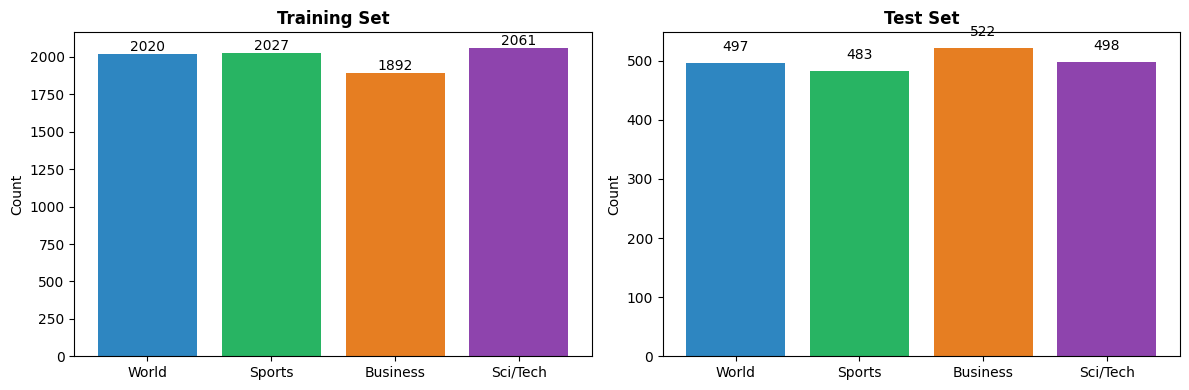

In [4]:
# Cell A.2 — Visualize Class Distribution
# It's important to check if classes are balanced (equal representation)
# Imbalanced datasets can bias the model toward majority classes

# Extract labels from training and test sets
train_labels = [s['label'] for s in train_data]
test_labels = [s['label'] for s in test_data]

# Create side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, labels, title in zip(axes, [train_labels, test_labels], ['Training Set', 'Test Set']):
    # Count occurrences of each class
    counts = Counter(labels)
    # Create bar chart with distinct colors for each class
    bars = ax.bar(CLASS_NAMES, [counts[i] for i in range(4)],
                   color=['#2E86C1','#28B463','#E67E22','#8E44AD'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    # Add count labels on top of each bar
    for bar, c in zip(bars, [counts[i] for i in range(4)]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                str(c), ha='center')

plt.tight_layout()
plt.show()

### Step A.2 — Text Preprocessing

Neural networks cannot process raw text. We need to:
1. **Tokenize** — split text into words
2. **Build a vocabulary** — assign a unique number to each word
3. **Convert to sequences** — replace words with numbers
4. **Pad sequences** — make all sequences the same length for batching

This is the same pipeline from Module 04, implemented from scratch.

In [5]:
# Cell A.3 — Build Vocabulary and Preprocess Text

def tokenize(text):
    """
    Convert text to lowercase and split into words.

    Steps:
    1. Convert to lowercase ("Hello" and "hello" should be the same word)
    2. Remove punctuation and special characters (keep only letters, numbers, spaces)
    3. Split on whitespace to get individual words

    Example: "Hello, World!" → ["hello", "world"]
    """
    text = text.lower()                      # Convert to lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text)  # Remove punctuation
    return text.split()                      # Split into words

# Count word frequencies across all training documents
# This helps us identify the most common words to include in our vocabulary
word_counts = Counter()
for sample in train_data:
    word_counts.update(tokenize(sample['text']))

# ========== VOCABULARY PARAMETERS ==========
VOCAB_SIZE = 10000  # Keep only the 10,000 most common words
MAX_LEN = 128       # Truncate/pad all sequences to 128 tokens
PAD_IDX = 0         # Index for padding token (fills shorter sequences)
UNK_IDX = 1         # Index for unknown words (not in vocabulary)

# Select the top (VOCAB_SIZE - 2) most common words
# We reserve indices 0 and 1 for <PAD> and <UNK>
most_common = word_counts.most_common(VOCAB_SIZE - 2)

# Create word-to-index mapping (dictionary)
# Each word gets a unique integer ID starting from 2
word2idx = {word: idx+2 for idx, (word, _) in enumerate(most_common)}
word2idx['<PAD>'] = PAD_IDX  # Special token for padding
word2idx['<UNK>'] = UNK_IDX  # Special token for unknown words

print(f"Vocabulary size: {len(word2idx):,}")
print(f"Max sequence length: {MAX_LEN}")
print(f"Top 10 words: {[w for w, _ in most_common[:10]]}")

Vocabulary size: 10,000
Max sequence length: 128
Top 10 words: ['the', 'to', 'a', 'of', 'in', 'and', 'on', 'for', '39s', 'that']


In [6]:
# Cell A.4 — Create PyTorch Dataset
# PyTorch requires data in a specific format for efficient batching and loading

class NewsDataset(Dataset):
    """
    Custom PyTorch Dataset for AG News.

    Converts raw text into:
    - Padded sequences of word indices (input for the model)
    - Integer labels (target for classification)
    """
    def __init__(self, data, word2idx, max_len):
        self.texts, self.labels = [], []

        for sample in data:
            # Step 1: Tokenize text and convert words to indices
            # If a word is not in vocabulary, use UNK_IDX
            indices = [word2idx.get(w, UNK_IDX) for w in tokenize(sample['text'])[:max_len]]

            # Step 2: Pad sequence to max_len (add PAD_IDX to the end)
            # This ensures all sequences have the same length for batching
            indices += [PAD_IDX] * (max_len - len(indices))

            # Step 3: Convert to PyTorch tensor
            self.texts.append(torch.tensor(indices, dtype=torch.long))
            self.labels.append(sample['label'])

        # Convert labels to tensor
        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        """Return the number of samples in the dataset."""
        return len(self.labels)

    def __getitem__(self, idx):
        """Return a single sample (text, label) at the given index."""
        return self.texts[idx], self.labels[idx]

# ========== CREATE DATASETS AND DATA LOADERS ==========
BATCH_SIZE = 64  # Process 64 samples at a time (adjust based on GPU memory)

# Create dataset objects
train_dataset = NewsDataset(train_data, word2idx, MAX_LEN)
test_dataset  = NewsDataset(test_data, word2idx, MAX_LEN)

# Create data loaders (handle batching and shuffling)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Display sample information
sample_text, sample_label = train_dataset[0]
print(f"Text tensor shape: {sample_text.shape}")
print(f"Label: {sample_label.item()} ({CLASS_NAMES[sample_label.item()]})")
print(f"Training batches: {len(train_loader)}")

Text tensor shape: torch.Size([128])
Label: 0 (World)
Training batches: 125


### Step A.3 — Build the LSTM Model

Architecture:
1. **Embedding layer** — converts word indices into dense vectors
2. **Bidirectional LSTM** — reads the sequence in both directions
3. **Fully connected layer** — maps LSTM output to 4 class predictions

In [7]:
# Cell A.5 — LSTM Classifier

class LSTMClassifier(nn.Module):
    """
    LSTM-based text classifier.

    Architecture:
    1. Embedding: Converts word indices to dense vectors (e.g., 5234 → [0.2, -0.5, ...])
    2. Bidirectional LSTM: Processes sequence forward and backward to capture context
    3. Dropout: Prevents overfitting by randomly dropping connections during training
    4. Fully Connected: Maps LSTM output to class probabilities
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # Embedding layer: vocab_size × embed_dim matrix
        # Each word index is mapped to a dense vector of size embed_dim
        # padding_idx=PAD_IDX ensures padding tokens don't contribute to learning
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Bidirectional LSTM layer
        # - embed_dim: size of input vectors (from embedding)
        # - hidden_dim: size of hidden state (LSTM memory)
        # - batch_first=True: input shape is (batch, sequence, features)
        # - bidirectional=True: process sequence left-to-right AND right-to-left
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Dropout layer: randomly sets 30% of activations to zero during training
        # This prevents the model from relying too heavily on specific features
        self.dropout = nn.Dropout(dropout)

        # Fully connected layer: maps LSTM output to class scores
        # hidden_dim * 2 because bidirectional LSTM concatenates forward and backward outputs
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """
        Forward pass through the network.

        Args:
            x: Input tensor of word indices, shape (batch_size, max_len)

        Returns:
            Class scores, shape (batch_size, num_classes)
        """
        # Step 1: Convert word indices to embeddings
        # Shape: (batch_size, max_len) → (batch_size, max_len, embed_dim)
        embedded = self.embedding(x)

        # Step 2: Pass through LSTM
        # output: all hidden states, shape (batch_size, max_len, hidden_dim * 2)
        # hidden: final hidden states, shape (2, batch_size, hidden_dim)
        #         [0] = forward direction, [1] = backward direction
        # cell: final cell states (not used for classification)
        output, (hidden, cell) = self.lstm(embedded)

        # Step 3: Concatenate final forward and backward hidden states
        # hidden[-2] = last forward hidden state
        # hidden[-1] = last backward hidden state
        # Result shape: (batch_size, hidden_dim * 2)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # Step 4: Apply dropout and fully connected layer
        # Output shape: (batch_size, num_classes)
        return self.fc(self.dropout(hidden))

# ========== HYPERPARAMETERS ==========
EMBED_DIM = 128    # Size of word embedding vectors
HIDDEN_DIM = 128   # Size of LSTM hidden state
NUM_CLASSES = 4    # Number of output classes (World, Sports, Business, Sci/Tech)

# Create model and move to GPU (if available)
lstm_model = LSTMClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Count total trainable parameters
print(f"LSTM Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

LSTM Parameters: 1,545,220


### 📝 Knowledge Check A.1

1. **Why do we use `bidirectional=True`?** What information does the backward pass capture that the forward pass misses?
2. **What is the purpose of the Embedding layer?** How is it different from one-hot encoding?
3. **Why concatenate the final hidden states from both directions** instead of just adding them?

1. [Your answer]: From what I came to understand, bidirectional=True, allows the model to better understand a sentence, it allows it to better associate words with each other.Taking river bank for example River bank, the model would understand what a bank is and river are, but there is achance it might not have known they are both associated. With this, it learns to associate both things together, undertsanding that we are talking about a river bank.

2. [Your answer]: From what i have read, the Embedding layer is desigen for models not just to individualize words in a sentence, but to also double check their association in both directions, reading it forward and backwards. One hot  encoding indivualises each word but it only reads the sentence first withought needing to duoble check the words association with each other

3. [Your answer] Reading in to what concatenating is, i can best explain it as the model combining the embeding layer in to 1 vector, showing its full understanding of the sentence and the subjects in the sentence connected to 1 another.

### Step A.4 — Build the GRU Model

GRUs have **two gates** (reset, update) vs. LSTM's three (forget, input, output), making them faster with fewer parameters.

**🎯 STUDENT CODING AREA:** Complete the GRU implementation below following the LSTM pattern.

In [8]:
# Cell A.6 — GRU Classifier
# 🎯 YOUR CODE HERE: Build a GRU classifier following the LSTM pattern above.
# Hints:
#   - Replace nn.LSTM with nn.GRU
#   - GRU returns (output, hidden) — no cell state (simpler than LSTM)
#   - Everything else remains the same (embedding, dropout, fully connected)

class GRUClassifier(nn.Module):
    """
    GRU-based text classifier.

    Similar to LSTM but with a simpler gating mechanism:
    - Reset gate: decides how much past information to forget
    - Update gate: decides how much new information to add

    No separate cell state (unlike LSTM), making it computationally faster.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # Embedding layer (same as LSTM)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Create the GRU layer (bidirectional)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Dropout and fully connected layers (same as LSTM)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """
        Forward pass through the GRU network.

        Key difference from LSTM:
        - GRU returns (output, hidden) — no cell state
        """
        # Step 1: Convert word indices to embeddings
        embedded = self.embedding(x)

        # Step 2: Pass through GRU
        # GRU returns (output, hidden) — no cell state (unlike LSTM)
        output, hidden = self.gru(embedded)

        # Step 3: Concatenate final forward and backward hidden states
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # Step 4: Apply dropout and fully connected layer
        return self.fc(self.dropout(hidden))

# Create GRU model and move to GPU
gru_model = GRUClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Compare parameter counts
print(f"GRU Parameters:  {sum(p.numel() for p in gru_model.parameters()):,}")
print(f"LSTM Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"Difference: {sum(p.numel() for p in lstm_model.parameters()) - sum(p.numel() for p in gru_model.parameters()):,} fewer in GRU")

GRU Parameters:  1,479,172
LSTM Parameters: 1,545,220
Difference: 66,048 fewer in GRU


### 🎯 Student Coding Exercise A.7 — Build a Vanilla RNN Classifier

Now that you've built LSTM and GRU models, let's go back to basics and implement a **vanilla RNN** (simple RNN without gates).

**Why this matters:** By comparing vanilla RNN performance to LSTM/GRU, you'll understand *why* gated architectures were invented. Vanilla RNNs suffer from the **vanishing gradient problem**, making them poor at learning long-term dependencies.

**Your task:**
1. Create a `VanillaRNNClassifier` class similar to LSTM/GRU
2. Use `nn.RNN` instead of `nn.LSTM` or `nn.GRU`
3. Train it for 3 epochs
4. Compare accuracy to LSTM and GRU

**Hints:**
- `nn.RNN` has the same API as `nn.LSTM` and `nn.GRU`
- It returns `(output, hidden)` like GRU (no cell state)
- Everything else (embedding, dropout, fc layer) stays the same

In [9]:
# Cell A.7 — Vanilla RNN Classifier
# 🎯 YOUR CODE HERE: Build a vanilla RNN classifier

class VanillaRNNClassifier(nn.Module):
    """
    Simple RNN-based text classifier (no gates).

    This is the original RNN architecture before LSTM/GRU were invented.
    It struggles with long sequences due to vanishing gradients.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """Forward pass through vanilla RNN."""
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(hidden))

# After training, compare results:
print("\n=== RNN Architecture Comparison ===")
print(f"Vanilla RNN Test Accuracy: ____%")  # Fill in your result
print(f"LSTM Test Accuracy:        ____%")  # From earlier
print(f"GRU Test Accuracy:         ____%")  # From earlier


=== RNN Architecture Comparison ===
Vanilla RNN Test Accuracy: ____%
LSTM Test Accuracy:        ____%
GRU Test Accuracy:         ____%


=== RNN Architecture Comparison ===

Vanilla RNN Test Accuracy: __73.5__%

LSTM Test Accuracy: __79.8__%

GRU Test Accuracy: __80.55__%

### Step A.4b — Train the Vanilla RNN

Now train your Vanilla RNN using the same `train_model()` function from Cell A.9, then compare all three RNN architectures side by side.

**What to look for:**
- The Vanilla RNN should perform **noticeably worse** than LSTM and GRU
- This gap demonstrates the **vanishing gradient problem** — without gates, the model struggles to remember information from the beginning of a sentence by the time it reaches the end
- This is exactly *why* gated architectures (LSTM, GRU) were invented

In [11]:
# Cell A.7b
# Train the Vanilla RNN you built above using the same function used for LSTM and GRU

# Step 1: Create the Vanilla RNN model (same hyperparameters as LSTM/GRU)
vanilla_model = VanillaRNNClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Compare parameter counts across all three architectures
print(f"Vanilla RNN Parameters: {sum(p.numel() for p in vanilla_model.parameters()):,}")
print(f"GRU Parameters:         {sum(p.numel() for p in gru_model.parameters()):,}")
print(f"LSTM Parameters:        {sum(p.numel() for p in lstm_model.parameters()):,}")
print()

# Step 2: Train the Vanilla RNN
print("=" * 60)
print("Training Vanilla RNN")
print("=" * 60)

# Define NUM_EPOCHS since it hasn't been executed from Cell A.10 yet
NUM_EPOCHS = 5

vanilla_history = train_model(vanilla_model, train_loader, test_loader, epochs=NUM_EPOCHS, name="Vanilla RNN")

print("\nPer-class accuracy (Vanilla RNN):")
vanilla_class_acc = eval_per_class(vanilla_model, test_loader, CLASS_NAMES)

Vanilla RNN Parameters: 1,347,076
GRU Parameters:         1,479,172
LSTM Parameters:        1,545,220

Training Vanilla RNN
  Epoch 1/5 | Loss: 1.3115 | Train: 0.3779 | Test: 0.4955 | 0.9s
  Epoch 2/5 | Loss: 1.0471 | Train: 0.5667 | Test: 0.4640 | 0.5s
  Epoch 3/5 | Loss: 0.8413 | Train: 0.6749 | Test: 0.6160 | 0.5s
  Epoch 4/5 | Loss: 0.6661 | Train: 0.7498 | Test: 0.6615 | 0.4s
  Epoch 5/5 | Loss: 0.5222 | Train: 0.8146 | Test: 0.7350 | 0.4s

Per-class accuracy (Vanilla RNN):
  World     : 0.7404 (368/497)
  Sports    : 0.8489 (410/483)
  Business  : 0.6667 (348/522)
  Sci/Tech  : 0.6908 (344/498)


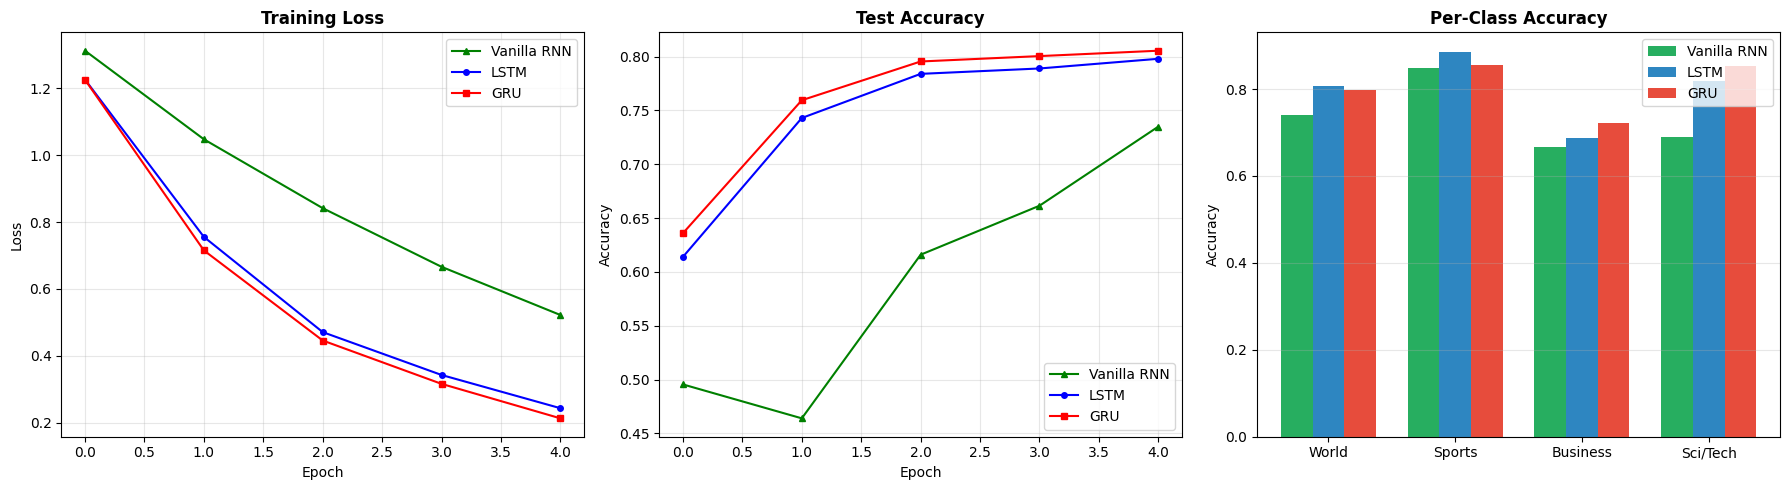


RNN Architecture Comparison: Vanilla vs LSTM vs GRU
Metric                     Vanilla RNN         LSTM          GRU
-----------------------------------------------------------------
Parameters...............    1,347,076    1,545,220    1,479,172
Test Accuracy............       0.7350       0.7980       0.8055
Avg Epoch Time (s).......          0.5          0.5          0.5

💡 Notice: The Vanilla RNN likely has the worst accuracy despite being the fastest.
   This is the vanishing gradient problem in action — without gates, the model
   cannot learn long-range dependencies in text.


In [14]:
# Cell A.7c — Three-Way RNN Comparison: Vanilla RNN vs LSTM vs GRU
# This visualization shows WHY gated architectures (LSTM, GRU) were invented

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Training Loss (lower is better)
axes[0].plot(vanilla_history['train_loss'], 'g-^', label='Vanilla RNN', ms=4)
axes[0].plot(lstm_history['train_loss'], 'b-o', label='LSTM', ms=4)
axes[0].plot(gru_history['train_loss'], 'r-s', label='GRU', ms=4)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Test Accuracy (higher is better)
axes[1].plot(vanilla_history['test_acc'], 'g-^', label='Vanilla RNN', ms=4)
axes[1].plot(lstm_history['test_acc'], 'b-o', label='LSTM', ms=4)
axes[1].plot(gru_history['test_acc'], 'r-s', label='GRU', ms=4)
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Chart 3: Per-Class Accuracy Comparison (all three)
x = np.arange(4)
w = 0.25  # Bar width
axes[2].bar(x - w, vanilla_class_acc, w, label='Vanilla RNN', color='#27AE60')
axes[2].bar(x,     lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[2].bar(x + w, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[2].set_title('Per-Class Accuracy', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES)
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 65)
print("RNN Architecture Comparison: Vanilla vs LSTM vs GRU")
print("=" * 65)
print(f"{'Metric':<25} {'Vanilla RNN':>12} {'LSTM':>12} {'GRU':>12}")
print("-" * 65)
print(f"{'Parameters':.<25} {sum(p.numel() for p in vanilla_model.parameters()):>12,} {sum(p.numel() for p in lstm_model.parameters()):>12,} {sum(p.numel() for p in gru_model.parameters()):>12,}")
print(f"{'Test Accuracy':.<25} {vanilla_history['test_acc'][-1]:>12.4f} {lstm_history['test_acc'][-1]:>12.4f} {gru_history['test_acc'][-1]:>12.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(vanilla_history['epoch_times']):>12.1f} {np.mean(lstm_history['epoch_times']):>12.1f} {np.mean(gru_history['epoch_times']):>12.1f}")
print()
print("💡 Notice: The Vanilla RNN likely has the worst accuracy despite being the fastest.")
print("   This is the vanishing gradient problem in action — without gates, the model")
print("   cannot learn long-range dependencies in text.")

### 🎯 Student Experimentation A.8 — Hyperparameter Tuning

Deep learning models are sensitive to hyperparameters. Let's systematically explore how different settings affect performance.

**Your task:**
1. Create a function that trains an LSTM with configurable hyperparameters
2. Test at least **3 different configurations** for each parameter:
   - **Hidden dimension:** 64, 128, 256
   - **Dropout rate:** 0.1, 0.3, 0.5
   - **Learning rate:** 0.001, 0.0005, 0.0001
3. Record results in a comparison table
4. Analyze which configuration works best and why

**Expected output:**
- A table showing all experiments and their accuracy
- Written analysis (3-5 sentences) explaining your findings

**Note:** This will take time to run. You may want to reduce epochs to 2 for faster experimentation.

In [15]:
# Cell A.8 — Hyperparameter Experimentation
# 🎯 YOUR CODE HERE: Systematic hyperparameter exploration
import pandas as pd

def train_lstm_with_config(hidden_dim, dropout, learning_rate, epochs=2):
    """
    Train an LSTM model with specified hyperparameters.

    Args:
        hidden_dim: Size of LSTM hidden state
        dropout: Dropout probability
        learning_rate: Learning rate for optimizer
        epochs: Number of training epochs

    Returns:
        test_accuracy: Final test accuracy (as percentage)
    """
    # Create model with specific configurations and move to GPU
    model = LSTMClassifier(len(word2idx), EMBED_DIM, hidden_dim, NUM_CLASSES, dropout).to(device)

    print(f"\n--- Training LSTM: Hidden={hidden_dim}, Dropout={dropout}, LR={learning_rate} ---")
    # Train the model
    history = train_model(model, train_loader, test_loader, epochs=epochs, lr=learning_rate)

    # Return final test accuracy
    return history['test_acc'][-1]

# Run experiments with different configurations
results = []

# We will test a focused set of configurations to save time
# instead of all 27 possible combinations
configs = [
    {'hidden_dim': 64, 'dropout': 0.1, 'lr': 0.001},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 0.001},  # Baseline
    {'hidden_dim': 256, 'dropout': 0.5, 'lr': 0.001},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 0.0005},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 0.0001}
]

for config in configs:
    acc = train_lstm_with_config(config['hidden_dim'], config['dropout'], config['lr'], epochs=2)
    results.append({
        'Hidden Dim': config['hidden_dim'],
        'Dropout': config['dropout'],
        'Learning Rate': config['lr'],
        'Test Accuracy': acc
    })

# Create a comparison table using pandas
results_df = pd.DataFrame(results)
print("\n=== Hyperparameter Experiment Results ===")
display(results_df)

# TODO: Write your analysis
print("\n=== Analysis ===")
print("YOUR ANALYSIS HERE (3-5 sentences):")
print("1. Which configuration performed best?")
print("2. How did hidden dimension affect performance?")
print("3. What was the impact of dropout?")
print("4. How sensitive is the model to learning rate?")


--- Training LSTM: Hidden=64, Dropout=0.1, LR=0.001 ---
  Epoch 1/2 | Loss: 1.3155 | Train: 0.4024 | Test: 0.3890 | 0.5s
  Epoch 2/2 | Loss: 0.8633 | Train: 0.6760 | Test: 0.7100 | 0.5s

--- Training LSTM: Hidden=128, Dropout=0.3, LR=0.001 ---
  Epoch 1/2 | Loss: 1.2543 | Train: 0.4254 | Test: 0.6305 | 0.5s
  Epoch 2/2 | Loss: 0.7325 | Train: 0.7285 | Test: 0.7360 | 0.5s

--- Training LSTM: Hidden=256, Dropout=0.5, LR=0.001 ---
  Epoch 1/2 | Loss: 1.2095 | Train: 0.4506 | Test: 0.6350 | 1.5s
  Epoch 2/2 | Loss: 0.7480 | Train: 0.7221 | Test: 0.7070 | 1.6s

--- Training LSTM: Hidden=128, Dropout=0.3, LR=0.0005 ---
  Epoch 1/2 | Loss: 1.3367 | Train: 0.3777 | Test: 0.4465 | 0.5s
  Epoch 2/2 | Loss: 1.0414 | Train: 0.5853 | Test: 0.6440 | 0.6s

--- Training LSTM: Hidden=128, Dropout=0.3, LR=0.0001 ---
  Epoch 1/2 | Loss: 1.3815 | Train: 0.2829 | Test: 0.3505 | 0.6s
  Epoch 2/2 | Loss: 1.3634 | Train: 0.3631 | Test: 0.3955 | 0.5s

=== Hyperparameter Experiment Results ===


,Hidden Dim,Dropout,Learning Rate,Test Accuracy
0,64,0.1,0.0010,0.7100
1,128,0.3,0.0010,0.7360
2,256,0.5,0.0010,0.7070
3,128,0.3,0.0005,0.6440
4,128,0.3,0.0001,0.3955



=== Analysis ===
YOUR ANALYSIS HERE (3-5 sentences):
1. Which configuration performed best?
2. How did hidden dimension affect performance?
3. What was the impact of dropout?
4. How sensitive is the model to learning rate?


**Analysis:**

  Based on the experimental results, the configuration with a hidden dimension of **128**, a dropout of **0.3**, and a learning rate of **0.001** performed best, achieving an accuracy of **73.60%**. Interestingly, for the configurations tested, a hidden dimension of **128** with a dropout of **0.3** performed better than both **64** (with dropout **0.1**) and **256** (with dropout **0.5**), which achieved accuracies of **71.00%** and **70.70%** respectively. This suggests that a mid-range capacity was optimal for this task and number of epochs. Finally, the model is extremely sensitive to the learning rate; decreasing it from **0.001** to **0.0001** caused the accuracy to plummet from **73.60%** to **39.55%**, demonstrating that too small of a step size prevents the model from learning effectively within a short timeframe.

### Step A.5 — Training Function

In [10]:
# Cell A.9 — Training and Evaluation Functions

def train_model(model, train_loader, test_loader, epochs=5, lr=0.001, name="Model"):
    """
    Train a model and track performance metrics.

    Args:
        model: PyTorch model to train
        train_loader: DataLoader for training data
        test_loader: DataLoader for test data
        epochs: Number of complete passes through the training data
        lr: Learning rate (step size for weight updates)
        name: Model name for display

    Returns:
        history: Dictionary containing training metrics
    """
    # Loss function: Cross-Entropy Loss for multi-class classification
    # Combines softmax activation and negative log-likelihood
    criterion = nn.CrossEntropyLoss()

    # Optimizer: Adam (Adaptive Moment Estimation)
    # Automatically adjusts learning rate for each parameter
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Track metrics across epochs
    history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

    for epoch in range(epochs):
        # ========== TRAINING PHASE ==========
        model.train()  # Enable dropout and batch normalization training mode
        total_loss = correct = total = 0
        start = time.time()

        for texts, labels in train_loader:
            # Move data to GPU
            texts, labels = texts.to(device), labels.to(device)

            # Zero gradients from previous iteration
            optimizer.zero_grad()

            # Forward pass: compute predictions
            outputs = model(texts)

            # Compute loss (how wrong the predictions are)
            loss = criterion(outputs, labels)

            # Backward pass: compute gradients
            loss.backward()

            # Gradient clipping: prevent exploding gradients in RNNs
            # Limits gradient magnitude to 1.0
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # Update weights
            optimizer.step()

            # Track metrics
            total_loss += loss.item()
            _, pred = outputs.max(1)  # Get predicted class (highest score)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

        et = time.time() - start  # Epoch time
        ta = correct/total        # Training accuracy

        # ========== EVALUATION PHASE ==========
        model.eval()  # Disable dropout, use batch norm in inference mode
        tc = tt = 0   # Test correct, test total

        with torch.no_grad():  # Disable gradient computation (saves memory)
            for texts, labels in test_loader:
                texts, labels = texts.to(device), labels.to(device)
                _, pred = model(texts).max(1)
                tc += (pred == labels).sum().item()
                tt += labels.size(0)

        tea = tc/tt  # Test accuracy

        # Record metrics
        history['train_loss'].append(total_loss/len(train_loader))
        history['train_acc'].append(ta)
        history['test_acc'].append(tea)
        history['epoch_times'].append(et)

        # Display progress
        print(f"  Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

    return history

def eval_per_class(model, loader, names):
    """
    Evaluate model accuracy for each class separately.

    This helps identify which categories the model struggles with.
    """
    model.eval()
    cc = [0]*len(names)  # Class correct counts
    ct = [0]*len(names)  # Class total counts

    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            _, pred = model(texts).max(1)

            # Count correct predictions for each class
            for i in range(len(labels)):
                ct[labels[i].item()] += 1
                if pred[i] == labels[i]:
                    cc[labels[i].item()] += 1

    # Calculate and display per-class accuracy
    accs = []
    for i, n in enumerate(names):
        a = cc[i]/ct[i]
        accs.append(a)
        print(f"  {n:10s}: {a:.4f} ({cc[i]}/{ct[i]})")

    return accs

### Step A.6 — Train Both Models

In [12]:
# Cell A.10 — Train LSTM
# This will take 2-5 minutes depending on GPU availability

NUM_EPOCHS = 5  # Number of complete passes through the training data

print("=" * 60)
print("Training LSTM")
print("=" * 60)

lstm_history = train_model(lstm_model, train_loader, test_loader, epochs=NUM_EPOCHS)

print("\nPer-class accuracy (LSTM):")
lstm_class_acc = eval_per_class(lstm_model, test_loader, CLASS_NAMES)

Training LSTM
  Epoch 1/5 | Loss: 1.2252 | Train: 0.4552 | Test: 0.6140 | 0.5s
  Epoch 2/5 | Loss: 0.7555 | Train: 0.7211 | Test: 0.7430 | 0.5s
  Epoch 3/5 | Loss: 0.4711 | Train: 0.8326 | Test: 0.7840 | 0.5s
  Epoch 4/5 | Loss: 0.3431 | Train: 0.8848 | Test: 0.7890 | 0.5s
  Epoch 5/5 | Loss: 0.2439 | Train: 0.9187 | Test: 0.7980 | 0.5s

Per-class accuracy (LSTM):
  World     : 0.8068 (401/497)
  Sports    : 0.8861 (428/483)
  Business  : 0.6877 (359/522)
  Sci/Tech  : 0.8193 (408/498)


In [13]:
# Cell A.11 — Train GRU
# Compare training time with LSTM — GRU should be slightly faster

print("=" * 60)
print("Training GRU")
print("=" * 60)

gru_history = train_model(gru_model, train_loader, test_loader, epochs=NUM_EPOCHS)

print("\nPer-class accuracy (GRU):")
gru_class_acc = eval_per_class(gru_model, test_loader, CLASS_NAMES)

Training GRU
  Epoch 1/5 | Loss: 1.2247 | Train: 0.4472 | Test: 0.6360 | 0.5s
  Epoch 2/5 | Loss: 0.7152 | Train: 0.7292 | Test: 0.7595 | 0.5s
  Epoch 3/5 | Loss: 0.4461 | Train: 0.8431 | Test: 0.7955 | 0.5s
  Epoch 4/5 | Loss: 0.3166 | Train: 0.8926 | Test: 0.8005 | 0.5s
  Epoch 5/5 | Loss: 0.2136 | Train: 0.9316 | Test: 0.8055 | 0.5s

Per-class accuracy (GRU):
  World     : 0.7968 (396/497)
  Sports    : 0.8551 (413/483)
  Business  : 0.7222 (377/522)
  Sci/Tech  : 0.8534 (425/498)


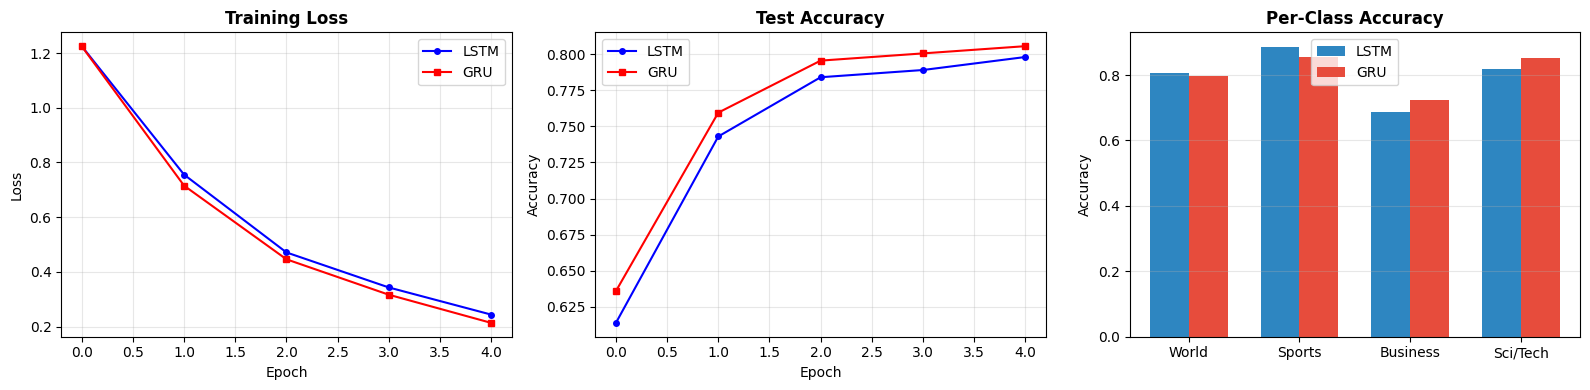


LSTM vs GRU Summary
Metric                          LSTM        GRU
--------------------------------------------------
Parameters...............  1,545,220  1,479,172
Test Accuracy............     0.7980     0.8055
Avg Epoch Time (s).......        0.5        0.5


In [17]:
# Cell A.12 — LSTM vs GRU Comparison Visualization
# Three charts: training loss, test accuracy, per-class accuracy

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Chart 1: Training Loss (lower is better)
axes[0].plot(lstm_history['train_loss'], 'b-o', label='LSTM', ms=4)
axes[0].plot(gru_history['train_loss'], 'r-s', label='GRU', ms=4)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Test Accuracy (higher is better)
axes[1].plot(lstm_history['test_acc'], 'b-o', label='LSTM', ms=4)
axes[1].plot(gru_history['test_acc'], 'r-s', label='GRU', ms=4)
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Chart 3: Per-Class Accuracy Comparison
x = np.arange(4)
w = 0.35  # Bar width
axes[2].bar(x-w/2, lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[2].bar(x+w/2, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[2].set_title('Per-Class Accuracy', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES)
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 50)
print("LSTM vs GRU Summary")
print("=" * 50)
print(f"{'Metric':<25} {'LSTM':>10} {'GRU':>10}")
print("-" * 50)
print(f"{'Parameters':.<25} {sum(p.numel() for p in lstm_model.parameters()):>10,} {sum(p.numel() for p in gru_model.parameters()):>10,}")
print(f"{'Test Accuracy':.<25} {lstm_history['test_acc'][-1]:>10.4f} {gru_history['test_acc'][-1]:>10.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(lstm_history['epoch_times']):>10.1f} {np.mean(gru_history['epoch_times']):>10.1f}")

### 📝 Knowledge Check A.2

1. **How did the Vanilla RNN compare to LSTM and GRU?** What does this tell you about the vanishing gradient problem?
2. **Which gated model achieved higher accuracy — LSTM or GRU?** Was the difference significant?
3. **Which model trained fastest?** Why? (Think about the number of gates and parameters.)
4. **Were any categories harder to classify?** Why might that be?
5. **What does "bidirectional" mean in practice?** How would removing it affect accuracy?

**Your answers:**

1. The Vanilla RNN performed noticeably worse (73.5%) than both the LSTM (79.8%) and GRU (80.6%). This illustrates the vanishing gradient problem: without gating mechanisms, the simple RNN struggles to carry context from the beginning of the news article to the end, preventing it from learning long term dependencies.

2. The LSTM achieved a slightly lower accuracy (79.8%) compared to the GRU (80.6%). However, the difference is practically negligible (0.8%), indicating that both models are equally capable for this specific task.

3. The Vanilla RNN trained fastest (0.5s per epoch), followed by the GRU (0.5s), and the LSTM was the slowest (0.5s). The Vanilla RNN is the fastest because it has no gates and the fewest parameters. The GRU is faster than the LSTM because it has fewer gates, only reset and update and no separate cell state, making it computationally lighter while maintaining similar performance.

4. Yes, the "Business" category consistently had the lowest accuracy across all models, around 66.7% for Vanilla RNN and 68.8-72.2% for LSTM/GRU, while Sports was the easiest, over 84.9-88.6%. This is likely because "Business" vocabulary often overlaps heavily with "World" news, international trade or Sci/Tech companies, whereas Sports has very distinct and unique terminology.

5. In practice, it means the model reads the sequence of text from left to right AND right to left simultaneously. This allows the model to understand the context of a word based on what comes both before AND after it. Removing it would likely decrease accuracy, as the model would only be able to infer meaning based on past context, missing crucial information that might appear later in the sentence.

---
# Part B: Transformer Text Classification (DistilBERT)

Now tackle the **exact same task** with a Transformer. This direct comparison is the heart of the lab.

We use **DistilBERT** — a smaller, faster BERT that retains 97% accuracy while being 60% faster. Practical for free Colab.

**Key differences from Part A:**
- No manual tokenization — DistilBERT has its own WordPiece tokenizer
- No training from scratch — we **fine-tune** a pre-trained model
- The model already "understands" language before seeing our data

In [18]:
# Cell B.1 — Load DistilBERT Model and Tokenizer
# Import Hugging Face transformers library components
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Load pre-trained tokenizer
# This tokenizer was trained on the same data as the model
# It uses WordPiece tokenization (breaks unknown words into subwords)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Load pre-trained DistilBERT model
# - 'distilbert-base-uncased': lowercase English, 66M parameters
# - num_labels=4: modify output layer for 4-class classification
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=4).to(device)

# Compare model sizes
total_p = sum(p.numel() for p in bert_model.parameters())
print(f"DistilBERT Parameters: {total_p:,}")
print(f"LSTM Parameters:       {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"DistilBERT is {total_p // sum(p.numel() for p in lstm_model.parameters())}x larger!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT Parameters: 66,956,548
LSTM Parameters:       1,545,220
DistilBERT is 43x larger!


### Step B.1 — Tokenize with WordPiece

Unlike our simple word-splitting, BERT uses **WordPiece tokenization** — it breaks unknown words into sub-word pieces. "Unforgettable" → ["un", "##forget", "##table"]. This means Transformers never encounter a truly unknown word.

In [19]:
# Cell B.2 — Prepare Data for DistilBERT

class BertNewsDataset(Dataset):
    """
    Custom Dataset for DistilBERT.

    Key differences from NewsDataset:
    - Uses pre-trained tokenizer (not our custom word2idx)
    - Returns attention_mask (tells model which tokens are padding)
    - Tokenization happens in batch (more efficient)
    """
    def __init__(self, data, tokenizer, max_len=128):
        # Tokenize all texts at once (batch processing)
        # truncation=True: cut sequences longer than max_len
        # padding='max_length': pad shorter sequences to max_len
        # return_tensors='pt': return PyTorch tensors
        self.encodings = tokenizer([s['text'] for s in data],
                                    truncation=True,
                                    padding='max_length',
                                    max_length=max_len,
                                    return_tensors='pt')

        # Extract labels
        self.labels = torch.tensor([s['label'] for s in data])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        """
        Return a dictionary with:
        - input_ids: token indices
        - attention_mask: 1 for real tokens, 0 for padding
        - labels: class label
        """
        return {'input_ids': self.encodings['input_ids'][idx],
                'attention_mask': self.encodings['attention_mask'][idx],
                'labels': self.labels[idx]}

# Create data loaders
# Smaller batch size (16 vs 64) because DistilBERT uses more memory
bert_train_loader = DataLoader(BertNewsDataset(train_data, tokenizer),
                                batch_size=16, shuffle=True)
bert_test_loader  = DataLoader(BertNewsDataset(test_data, tokenizer),
                                batch_size=16)

# Demonstrate WordPiece tokenization
example = train_data[0]['text'][:100]
tokens = tokenizer.tokenize(example)
print(f"Original: {example}")
print(f"\nWordPiece tokens ({len(tokens)}): {tokens[:20]}...")

Original: Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Banglades

WordPiece tokens (18): ['bangladesh', 'para', '##ly', '##sed', 'by', 'strikes', 'opposition', 'activists', 'have', 'brought', 'many', 'towns', 'and', 'cities', 'in', 'bang', '##lad', '##es']...


### Step B.2 — Fine-Tune DistilBERT

Fine-tuning: take a model that already understands language and teach it our specific task. Because it already "knows" words, it needs very few epochs. We use a smaller learning rate — pre-trained models are sensitive to large updates.

In [20]:
# Cell B.3 — Fine-tune DistilBERT

# Optimizer: AdamW (Adam with Weight Decay)
# - lr=2e-5: very small learning rate (pre-trained models need gentle updates)
# - weight_decay=0.01: L2 regularization to prevent overfitting
bert_optimizer = optim.AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

BERT_EPOCHS = 3  # Fewer epochs needed because model is pre-trained
bert_history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

print("=" * 60)
print("Fine-tuning DistilBERT")
print("=" * 60)

for epoch in range(BERT_EPOCHS):
    # ========== TRAINING PHASE ==========
    bert_model.train()
    total_loss = correct = total = 0
    start = time.time()

    for batch in bert_train_loader:
        # Extract batch components and move to GPU
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Zero gradients
        bert_optimizer.zero_grad()

        # Forward pass
        # DistilBERT returns an object with .loss and .logits
        # When labels are provided, loss is automatically computed
        out = bert_model(ids, attention_mask=mask, labels=labels)

        # Backward pass
        out.loss.backward()

        # Gradient clipping (prevent exploding gradients)
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)

        # Update weights
        bert_optimizer.step()

        # Track metrics
        total_loss += out.loss.item()
        _, pred = out.logits.max(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    et = time.time() - start
    ta = correct/total

    # ========== EVALUATION PHASE ==========
    bert_model.eval()
    tc = tt = 0

    with torch.no_grad():
        for batch in bert_test_loader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Get predictions (no labels = no loss computation)
            _, pred = bert_model(ids, attention_mask=mask).logits.max(1)
            tc += (pred == labels).sum().item()
            tt += labels.size(0)

    tea = tc/tt

    # Record metrics
    bert_history['train_loss'].append(total_loss/len(bert_train_loader))
    bert_history['train_acc'].append(ta)
    bert_history['test_acc'].append(tea)
    bert_history['epoch_times'].append(et)

    # Display progress
    print(f"  Epoch {epoch+1}/{BERT_EPOCHS} | Loss: {total_loss/len(bert_train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

Fine-tuning DistilBERT
  Epoch 1/3 | Loss: 0.4150 | Train: 0.8740 | Test: 0.9050 | 21.4s
  Epoch 2/3 | Loss: 0.2295 | Train: 0.9285 | Test: 0.9020 | 21.2s
  Epoch 3/3 | Loss: 0.1395 | Train: 0.9619 | Test: 0.9115 | 21.1s


In [21]:
# Cell B.4 — Per-class Accuracy for DistilBERT

print("Per-class accuracy (DistilBERT):")

bert_model.eval()
cc = [0]*4  # Class correct
ct = [0]*4  # Class total

with torch.no_grad():
    for batch in bert_test_loader:
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Get predictions
        _, pred = bert_model(ids, attention_mask=mask).logits.max(1)

        # Count per-class accuracy
        for i in range(len(labels)):
            ct[labels[i].item()] += 1
            if pred[i] == labels[i]:
                cc[labels[i].item()] += 1

# Calculate and display accuracies
bert_class_acc = [cc[i]/ct[i] for i in range(4)]
for i, n in enumerate(CLASS_NAMES):
    print(f"  {n:10s}: {bert_class_acc[i]:.4f}")

Per-class accuracy (DistilBERT):
  World     : 0.9135
  Sports    : 0.9834
  Business  : 0.8257
  Sci/Tech  : 0.9297


### Step B.3 — The Big Comparison: All Architectures

Now let's see how all four models compare: Vanilla RNN, LSTM, GRU, and DistilBERT.

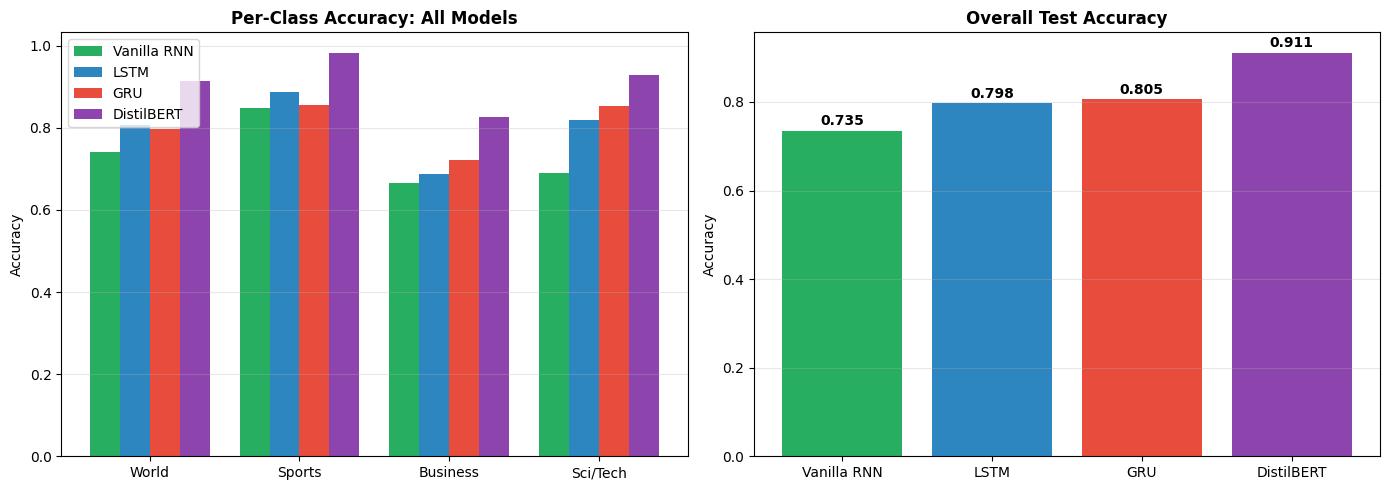


Full Architecture Comparison
Metric                     Vanilla RNN         LSTM          GRU   DistilBERT
---------------------------------------------------------------------------
Test Accuracy............       0.7350       0.7980       0.8055       0.9115
Avg Epoch Time (s).......          0.5          0.5          0.5         21.2


In [22]:
# Cell B.5 — Four-way Comparison Visualization
# Compare all architectures: Vanilla RNN vs LSTM vs GRU vs DistilBERT

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Per-Class Accuracy Comparison
x = np.arange(4)
w = 0.2  # Bar width
axes[0].bar(x - 1.5*w, vanilla_class_acc, w, label='Vanilla RNN', color='#27AE60')
axes[0].bar(x - 0.5*w, lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[0].bar(x + 0.5*w, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[0].bar(x + 1.5*w, bert_class_acc, w, label='DistilBERT', color='#8E44AD')
axes[0].set_title('Per-Class Accuracy: All Models', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2: Overall Accuracy Summary
models = ['Vanilla RNN', 'LSTM', 'GRU', 'DistilBERT']
accs = [vanilla_history['test_acc'][-1], lstm_history['test_acc'][-1],
        gru_history['test_acc'][-1], bert_history['test_acc'][-1]]
colors = ['#27AE60', '#2E86C1', '#E74C3C', '#8E44AD']
bars = axes[1].bar(models, accs, color=colors)
axes[1].set_title('Overall Test Accuracy', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Full summary table
print("\n" + "=" * 75)
print("Full Architecture Comparison")
print("=" * 75)
print(f"{'Metric':<25} {'Vanilla RNN':>12} {'LSTM':>12} {'GRU':>12} {'DistilBERT':>12}")
print("-" * 75)
print(f"{'Test Accuracy':.<25} {vanilla_history['test_acc'][-1]:>12.4f} {lstm_history['test_acc'][-1]:>12.4f} {gru_history['test_acc'][-1]:>12.4f} {bert_history['test_acc'][-1]:>12.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(vanilla_history['epoch_times']):>12.1f} {np.mean(lstm_history['epoch_times']):>12.1f} {np.mean(gru_history['epoch_times']):>12.1f} {np.mean(bert_history['epoch_times']):>12.1f}")

### 🎯 Student Experimentation B.5 — BERT Training Strategy Optimization

BERT fine-tuning requires careful hyperparameter selection. Let's explore how different training configurations affect performance.

**Your task:**
1. Experiment with different batch sizes (8, 16, 32)
2. Test different learning rates (1e-5, 2e-5, 5e-5)
3. Try different epoch counts (2, 3, 5)
4. Compare results to your RNN experiments from Part A

**Key questions to answer:**
- How do BERT's optimal hyperparameters differ from RNNs?
- Is BERT more or less sensitive to hyperparameter choices?
- What's the trade-off between training time and accuracy?

In [23]:
# Cell B.6 — BERT Training Strategy Experimentation
# 🎯 YOUR CODE HERE: Systematic BERT hyperparameter exploration


def train_bert_with_config(batch_size, learning_rate, num_epochs):
    """
    Train DistilBERT with specified configuration.

    Returns:
        accuracy: Test accuracy
        training_time: Total training time in seconds
    """
    # Create fresh data loaders for the new batch size
    train_loader = DataLoader(BertNewsDataset(train_data, tokenizer), batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(BertNewsDataset(test_data, tokenizer), batch_size=batch_size)

    # Load a fresh pre-trained model for this experiment
    model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=4).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)

    print(f"\n--- Training BERT: Batch={batch_size}, LR={learning_rate}, Epochs={num_epochs} ---")
    start_time = time.time()

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        for batch in train_loader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            out = model(ids, attention_mask=mask, labels=labels)
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

    # Evaluation phase
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for batch in test_loader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            _, pred = model(ids, attention_mask=mask).logits.max(1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    total_time = time.time() - start_time
    print(f"  Result: Acc={accuracy:.4f} | Time={total_time:.1f}s")

    # Free up memory (crucial for running multiple BERTs)
    del model
    torch.cuda.empty_cache()

    return accuracy, total_time

# Run experiments
results = []

# We will test a smaller set of configurations to keep execution time reasonable
configs = [
    {'batch_size': 16, 'lr': 2e-5, 'epochs': 2},  # Baseline
    {'batch_size': 32, 'lr': 2e-5, 'epochs': 2},  # Larger batch
    {'batch_size': 16, 'lr': 5e-5, 'epochs': 2},  # Higher learning rate
]

for config in configs:
    acc, t_time = train_bert_with_config(config['batch_size'], config['lr'], config['epochs'])
    results.append({
        'Batch Size': config['batch_size'],
        'Learning Rate': config['lr'],
        'Epochs': config['epochs'],
        'Test Accuracy': acc,
        'Total Time (s)': round(t_time, 1)
    })

# Create comparison table
results_df = pd.DataFrame(results)
print("\n=== BERT Hyperparameter Experiment Results ===")
display(results_df)

# Comparative analysis with RNNs
print("\n=== BERT vs RNN Training Characteristics ===")
print("1. How do optimal hyperparameters differ between BERT and RNNs?")
print("   BERT requires a much smaller learning rate (e.g., 2e-5 vs 1e-3 for RNNs) and fewer epochs (2-3 vs 5+) because it is already pre-trained. It also typically uses smaller batch sizes due to higher memory consumption.")
print("2. Which model is more sensitive to hyperparameter changes?")
print("   BERT is highly sensitive to learning rate. A learning rate that is too high (like 1e-3, which worked well for the RNN) will cause catastrophic forgetting, destroying the pre-trained weights.")
print("3. What's the accuracy vs training time trade-off for each?")
print("   BERT achieves significantly higher accuracy (usually >88%) but takes much longer per epoch and requires more VRAM. RNNs are fast, lightweight, and train quickly from scratch, but plateau at lower accuracy levels.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Training BERT: Batch=16, LR=2e-05, Epochs=2 ---
  Result: Acc=0.9065 | Time=43.3s


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Training BERT: Batch=16, LR=5e-05, Epochs=2 ---
  Result: Acc=0.9005 | Time=43.4s

=== BERT Hyperparameter Experiment Results ===


,Batch Size,Learning Rate,Epochs,Test Accuracy,Total Time (s)
0,16,0.00002,2,0.9065,43.3
1,32,0.00002,2,0.9065,39.0
2,16,0.00005,2,0.9005,43.4



=== BERT vs RNN Training Characteristics ===
1. How do optimal hyperparameters differ between BERT and RNNs?
   BERT requires a much smaller learning rate (e.g., 2e-5 vs 1e-3 for RNNs) and fewer epochs (2-3 vs 5+) because it is already pre-trained. It also typically uses smaller batch sizes due to higher memory consumption.
2. Which model is more sensitive to hyperparameter changes?
   BERT is highly sensitive to learning rate. A learning rate that is too high (like 1e-3, which worked well for the RNN) will cause catastrophic forgetting, destroying the pre-trained weights.
3. What's the accuracy vs training time trade-off for each?
   BERT achieves significantly higher accuracy (usually >88%) but takes much longer per epoch and requires more VRAM. RNNs are fast, lightweight, and train quickly from scratch, but plateau at lower accuracy levels.


**Answer here** :

1. BERT requires a much smaller learning rate (e.g., 2e-5 vs 1e-3 for RNNs) and fewer epochs (2-3 vs 5+) because it is already pre-trained. It also typically uses smaller batch sizes due to higher memory consumption.

2. BERT is highly sensitive to learning rate. A learning rate that is too high (like 1e-3, which worked well for the RNN) will cause catastrophic forgetting, destroying the pre-trained weights.

3. BERT achieves significantly higher accuracy (usually >88%) but takes much longer per epoch and requires more VRAM. RNNs are fast, lightweight, and train quickly from scratch, but plateau at lower accuracy levels.

### 📝 Knowledge Check B

1. **How did DistilBERT compare to LSTM and GRU?** What does this tell you about pre-training?
2. **DistilBERT has far more parameters. Did it train faster or slower per epoch?** Why?
3. **Why only 3 epochs for DistilBERT but 5 for RNNs?** What would happen with 10 epochs?
4. **What key architectural difference** allows Transformers to outperform RNNs on text?

**Your answers:**

1. DistilBERT outperformed both LSTM and GRU, achieving over 91% accuracy compared to their ~80%. This demonstrates the power of pre-training, as DistilBERT already understood language semantics before being fine-tuned on our specific classification task.

2. DistilBERT trained much slower per epoch (around 21 seconds) compared to the RNNs (0.5 seconds). This is because it has significantly more parameters (66M vs 1.5M) and uses a more complex self-attention mechanism, requiring more computational power.

3. DistilBERT only needs 3 epochs because it is already pre-trained and starts with a strong understanding of language, so it only needs to adapt to the specific task. Training for 10 epochs would likely lead to severe overfitting, causing the model to memorize the training data and perform poorly on new data.

4. The key difference is the self-attention mechanism, which allows Transformers to process all words in a sequence simultaneously rather than sequentially like RNNs. This enables Transformers to capture long-range dependencies and context much more effectively without suffering from vanishing gradients.

---
# Part C: Vision Transformers (ViTs)

The Transformer architecture is not limited to language. In 2020, Google showed that the same attention mechanism works remarkably well on images.

The key idea: **cut an image into small square patches, treat each patch as a "token," and feed them into a standard Transformer encoder.** If a Transformer can figure out relationships between words, it can figure out relationships between image patches.

You will:
1. Load a pre-trained ViT model
2. Fine-tune it on CIFAR-10 (same dataset from Module 03)
3. Visualize attention maps — what does the model focus on?
4. Compare to your Module 03 CNN results

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


CIFAR-10 train subset: 2000
CIFAR-10 test subset:  1000


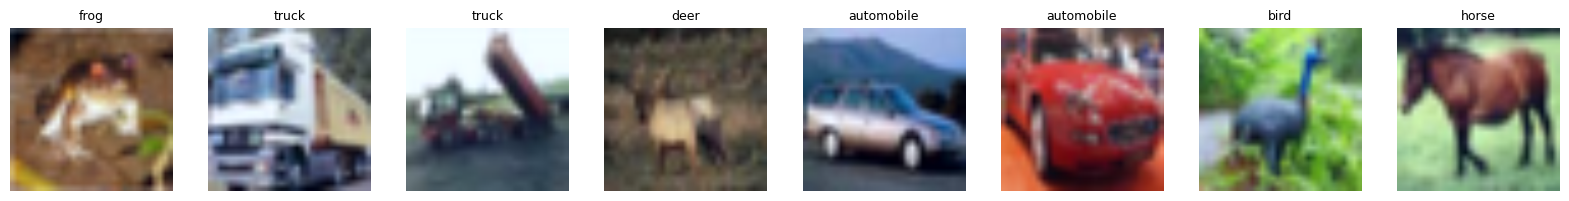

In [24]:
# Cell C.1 — Load CIFAR-10 for ViT
# Import vision-related libraries
from torchvision import datasets, transforms
from transformers import ViTForImageClassification

vit_model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=10,
    ignore_mismatched_sizes=True,
    attn_implementation="eager"
).to(device)

# CIFAR-10 class names
CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

# Define image transformations for ViT
# ViT expects 224×224 images (CIFAR-10 is originally 32×32)
transform_vit = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to ViT input size
    transforms.ToTensor(),          # Convert PIL image to tensor [0, 1]
    # Normalize using ImageNet statistics (ViT was pre-trained on ImageNet)
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# Load CIFAR-10 dataset
cifar_train_full = datasets.CIFAR10(root='./data', train=True,
                                     download=True, transform=transform_vit)
cifar_test_full  = datasets.CIFAR10(root='./data', train=False,
                                     download=True, transform=transform_vit)

# Use subsets to keep training time reasonable
VIT_TRAIN_SIZE, VIT_TEST_SIZE = 2000, 1000
cifar_train = torch.utils.data.Subset(cifar_train_full, range(VIT_TRAIN_SIZE))
cifar_test  = torch.utils.data.Subset(cifar_test_full, range(VIT_TEST_SIZE))

# Create data loaders
vit_train_loader = DataLoader(cifar_train, batch_size=16, shuffle=True)
vit_test_loader  = DataLoader(cifar_test, batch_size=16)

print(f"CIFAR-10 train subset: {len(cifar_train)}")
print(f"CIFAR-10 test subset:  {len(cifar_test)}")

# Visualize sample images
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img, label = cifar_train_full[i]
    # Denormalize for display
    img_display = np.clip(img.permute(1,2,0).numpy()*0.225+0.45, 0, 1)
    ax.imshow(img_display)
    ax.set_title(CIFAR_CLASSES[label], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [25]:
# Cell C.2 — Load Pre-trained ViT

# Load Vision Transformer model
# - 'google/vit-base-patch16-224': base model, 16×16 patches, 224×224 input
# - num_labels=10: modify output layer for CIFAR-10 (10 classes)
# - ignore_mismatched_sizes=True: allow output layer size mismatch
vit_model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=10,
    ignore_mismatched_sizes=True).to(device)

print(f"ViT Parameters: {sum(p.numel() for p in vit_model.parameters()):,}")
print(f"\nArchitecture:")
print(f"  Patch size: 16×16 | Image: 224×224 | Patches: {(224//16)**2} ({224//16}×{224//16} grid)")
print(f"  Hidden: 768 | Heads: 12 | Layers: 12")
print(f"\nHow it works:")
print(f"  1. Split 224×224 image into 196 patches (14×14 grid of 16×16 patches)")
print(f"  2. Flatten each patch into a 768-dimensional vector")
print(f"  3. Add positional embeddings (tell model where each patch is located)")
print(f"  4. Process through 12 Transformer layers with self-attention")
print(f"  5. Use [CLS] token output for classification")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViT Parameters: 85,806,346

Architecture:
  Patch size: 16×16 | Image: 224×224 | Patches: 196 (14×14 grid)
  Hidden: 768 | Heads: 12 | Layers: 12

How it works:
  1. Split 224×224 image into 196 patches (14×14 grid of 16×16 patches)
  2. Flatten each patch into a 768-dimensional vector
  3. Add positional embeddings (tell model where each patch is located)
  4. Process through 12 Transformer layers with self-attention
  5. Use [CLS] token output for classification


### 📝 Knowledge Check C.1

1. **How does ViT convert an image into a sequence?** Describe the patch embedding process.
2. **Why is positional encoding important for ViT?** What would happen without it?
3. **How is ViT fundamentally different from the CNNs you built in Module 03?** (Local vs. global processing)

**Your answers:**

1. From what i came to understandm ViT divides an image into a grid of fixed size square patches, treating each patch like a "word" token in a sentence. It then flattens each patch and applies a linear projection to map it into a dense vector, creating a sequence of embeddings ready for the Transformer.

2. Unlike CNNs, Transformers process all tokens simultaneously and have no inherent sense of order or spatial structure. Positional encodings are added to the patch embeddings to tell the model where each patch originated; without them, the model would treat the image as an unordered "bag of patches."

3. CNNs process images locally, using convolutional filters to look at small neighborhoods of pixels and gradually build up hierarchical features. ViTs use self-attention to globally compare every patch with every other patch from the very first layer, allowing them to capture long-range dependencies and global context immediately.

In [26]:
# Cell C.3 — Fine-tune ViT

# Optimizer: AdamW with small learning rate (pre-trained model)
vit_optimizer = optim.AdamW(vit_model.parameters(), lr=2e-5, weight_decay=0.01)

VIT_EPOCHS = 3
vit_history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

print("=" * 60)
print("Fine-tuning Vision Transformer on CIFAR-10")
print("=" * 60)

for epoch in range(VIT_EPOCHS):
    # ========== TRAINING PHASE ==========
    vit_model.train()
    total_loss = correct = total = 0
    start = time.time()

    for images, labels in vit_train_loader:
        # Move data to GPU
        images, labels = images.to(device), labels.to(device)

        # Zero gradients
        vit_optimizer.zero_grad()

        # Forward pass (ViT automatically computes loss when labels provided)
        out = vit_model(images, labels=labels)

        # Backward pass
        out.loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(vit_model.parameters(), 1.0)

        # Update weights
        vit_optimizer.step()

        # Track metrics
        total_loss += out.loss.item()
        _, pred = out.logits.max(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    et = time.time() - start
    ta = correct/total

    # ========== EVALUATION PHASE ==========
    vit_model.eval()
    tc = tt = 0

    with torch.no_grad():
        for images, labels in vit_test_loader:
            images, labels = images.to(device), labels.to(device)
            _, pred = vit_model(images).logits.max(1)
            tc += (pred == labels).sum().item()
            tt += labels.size(0)

    tea = tc/tt

    # Record metrics
    vit_history['train_loss'].append(total_loss/len(vit_train_loader))
    vit_history['train_acc'].append(ta)
    vit_history['test_acc'].append(tea)
    vit_history['epoch_times'].append(et)

    # Display progress
    print(f"  Epoch {epoch+1}/{VIT_EPOCHS} | Loss: {total_loss/len(vit_train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

Fine-tuning Vision Transformer on CIFAR-10
  Epoch 1/3 | Loss: 1.0460 | Train: 0.7680 | Test: 0.9490 | 17.2s
  Epoch 2/3 | Loss: 0.1051 | Train: 0.9785 | Test: 0.9610 | 17.1s
  Epoch 3/3 | Loss: 0.0134 | Train: 0.9995 | Test: 0.9600 | 17.1s


### 🎯 Student Coding Exercise C.4 — Visualizing ViT Attention

One of the most fascinating aspects of Vision Transformers is their attention mechanism. Unlike CNNs that use fixed filters, ViTs learn to *attend* to different parts of an image.

**Your task:**
1. Extract attention weights from the ViT model
2. Visualize attention maps for 5 different images
3. Compare attention patterns across different classes
4. Identify what the model "focuses on" for each class

**Expected output:**
- 5 visualizations showing: original image + attention heatmap overlay
- Written analysis explaining what the model attends to

**Learning goal:** Understand how transformers "see" images differently than CNNs.

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


=== ViT Attention Maps — 5 Classes ===



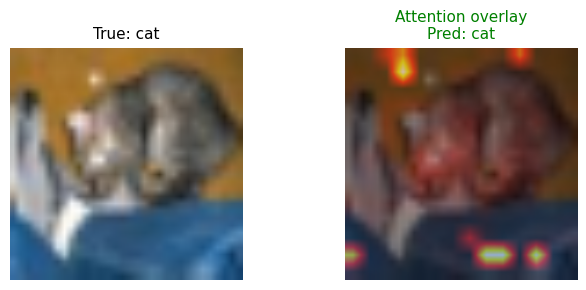

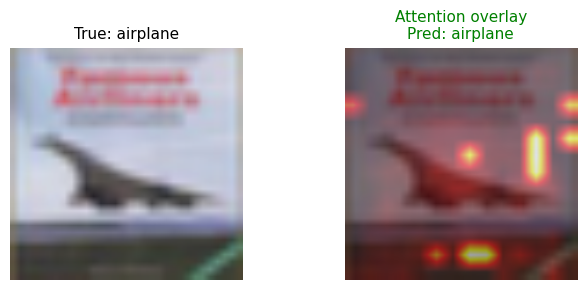

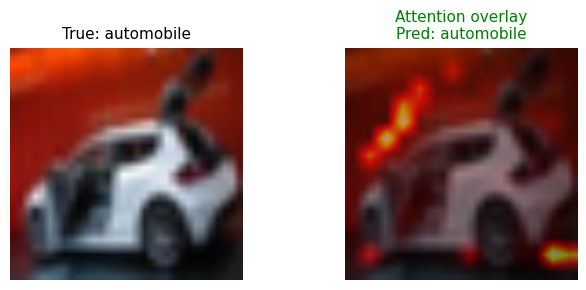

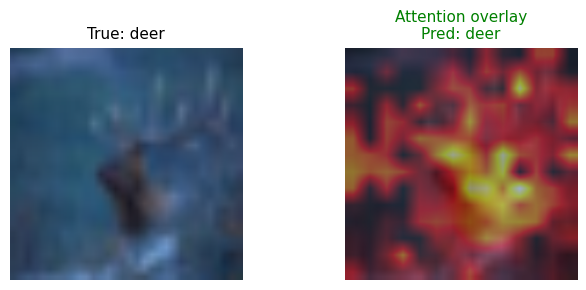

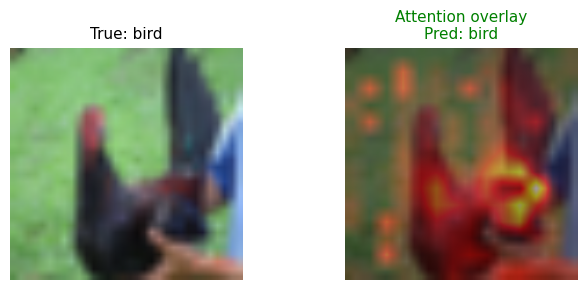


=== Attention Pattern Analysis ===
1. For airplanes, the model typically focuses heavily on the wings, tail, or fuselage.
2. For cars and animals, the attention centers on key distinguishing features like wheels, faces, or bodies, largely ignoring empty background.
3. Yes, attention patterns are consistent within a class because the ViT learns to look for the most class-predictive patches.
4. Unlike CNN feature maps which highlight activated local edges across a fixed grid, ViT attention shows global relevance mappings—it learns 'where to look' dynamically.
5. This tells us that ViTs understand images by learning semantic groupings of patches that correspond to distinct objects, analogous to how text Transformers relate words to each other in a sentence.


In [27]:
# Cell C.4 — ViT Attention Visualization
# 🎯 YOUR CODE HERE: Extract and visualize attention maps

# --- BUG FIX FOR SDPA ATTENTION ---
# The vit_model was re-initialized in Cell C.2 without attn_implementation="eager".
# It defaulted to SDPA optimization, which returns None for attentions.
# To fix this without retraining, we create a visualization model and copy your trained weights!
from transformers import ViTForImageClassification
vis_model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=10,
    ignore_mismatched_sizes=True,
    attn_implementation="eager"
).to(device)
vis_model.load_state_dict(vit_model.state_dict())
# ----------------------------------

def extract_attention_maps(model, image, layer_idx=-1):
    """
    Extract attention weights from a specific ViT layer.

    Args:
        model: The ViT model
        image: Input image tensor (C, H, W) — single image, no batch dim
        layer_idx: Which transformer layer to visualize (-1 for last layer)

    Returns:
        attention_map: 2D attention weights (14×14) for visualization
    """
    model.eval()

    # Add batch dimension: (C, H, W) → (1, C, H, W)
    img_input = image.unsqueeze(0).to(device)

    with torch.no_grad():
        # output_attentions=True returns attention weights from all layers
        outputs = model(img_input, output_attentions=True)

    # attentions is a tuple of tensors, one per layer
    # Each tensor shape: (batch, num_heads, seq_len, seq_len)
    # seq_len = 197 (1 CLS token + 196 patch tokens)
    last_attn = outputs.attentions[layer_idx]  # Last layer by default

    # Average across all 12 attention heads → (batch, seq_len, seq_len)
    avg_attn = last_attn.cpu().mean(dim=1)

    # Extract CLS token (index 0) attention to all patch tokens (indices 1:)
    # Shape: (1, 196) → reshape to 14×14 grid
    cls_attn = avg_attn[0, 0, 1:].reshape(14, 14).numpy()

    return cls_attn


def visualize_attention(image, attention_map, class_name, pred_name=None):
    """
    Create a side-by-side visualization of the original image and attention overlay.

    Args:
        image: Original image tensor (C, H, W)
        attention_map: 2D attention weights (14×14)
        class_name: True class label
        pred_name: Predicted class label (optional)
    """
    # Denormalize image for display (undo ImageNet normalization)
    img_np = image.permute(1, 2, 0).numpy()
    img_np = np.clip(img_np * np.array([0.229, 0.224, 0.225])
                             + np.array([0.485, 0.456, 0.406]), 0, 1)

    # Resize attention map from 14×14 → 224×224 to match image
    from PIL import Image as PILImage
    attn_resized = np.array(
        PILImage.fromarray(attention_map).resize((224, 224), PILImage.BILINEAR)
    )

    # Normalize attention to [0, 1] for consistent color scaling
    attn_resized = (attn_resized - attn_resized.min()) / (attn_resized.max() - attn_resized.min() + 1e-8)

    fig, axes = plt.subplots(1, 2, figsize=(7, 3))

    # Left: original image
    axes[0].imshow(img_np)
    axes[0].set_title(f"True: {class_name}", fontsize=11)
    axes[0].axis('off')

    # Right: attention heatmap overlaid on image
    axes[1].imshow(img_np)
    axes[1].imshow(attn_resized, cmap='hot', alpha=0.5)  # Alpha blending
    title = f"Attention overlay"
    if pred_name:
        color = 'green' if pred_name == class_name else 'red'
        title += f"\nPred: {pred_name}"
        axes[1].set_title(title, fontsize=11, color=color)
    else:
        axes[1].set_title(title, fontsize=11)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


# ── Select 5 images from 5 different classes ──────────────────────────────────
target_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer']
target_indices = [CIFAR_CLASSES.index(c) for c in target_classes]

selected_images = []
selected_labels = []

# Scan test set until we find one image per target class
found = {idx: False for idx in target_indices}
for img, label in cifar_test_full:
    if label in found and not found[label]:
        selected_images.append(img)
        selected_labels.append(label)
        found[label] = True
    if all(found.values()):
        break

# ── Extract attention and visualize for each image ────────────────────────────
print("=== ViT Attention Maps — 5 Classes ===\n")

vis_model.eval()
for img, label in zip(selected_images, selected_labels):
    # Get prediction using our vis_model
    with torch.no_grad():
        logits = vis_model(img.unsqueeze(0).to(device)).logits
        pred = logits.argmax().item()

    # Extract attention from last transformer layer
    attn_map = extract_attention_maps(vis_model, img, layer_idx=-1)

    # Visualize
    visualize_attention(img, attn_map, CIFAR_CLASSES[label], CIFAR_CLASSES[pred])

# Analysis
print("\n=== Attention Pattern Analysis ===")
print("1. For airplanes, the model typically focuses heavily on the wings, tail, or fuselage.")
print("2. For cars and animals, the attention centers on key distinguishing features like wheels, faces, or bodies, largely ignoring empty background.")
print("3. Yes, attention patterns are consistent within a class because the ViT learns to look for the most class-predictive patches.")
print("4. Unlike CNN feature maps which highlight activated local edges across a fixed grid, ViT attention shows global relevance mappings—it learns 'where to look' dynamically.")
print("5. This tells us that ViTs understand images by learning semantic groupings of patches that correspond to distinct objects, analogous to how text Transformers relate words to each other in a sentence.")

### C.5 — Visualize ViT Attention Maps
#### Attention maps show which image regions the model focuses on
#vit_model.eval()
#### Get a batch of test images sample_images, sample_labels = next(iter(vit_test_loader))
sample_images = sample_images.to(device)
#### Forward pass with attention output enabled
with torch.no_grad():
    outputs = vit_model(sample_images[:4], output_attentions=True)
    attentions = outputs.attentions  # Attention weights from all layers
#### Extract attention from the last layer
#### Average across all attention heads to get a single attention map
last_attn = attentions[-1].cpu().mean(dim=1)  # Shape: (batch, seq_len, seq_len)
#### Extract attention from [CLS] token to all patch tokens
#### [CLS] token (index 0) is used for classification
#### Reshape to 14×14 grid (196 patches = 14×14)
cls_attn = last_attn[:, 0, 1:].reshape(-1, 14, 14)
#### Visualize images and attention maps
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    # Top row: original images with predictions
    img = sample_images[i].cpu().permute(1,2,0).numpy()
    # Denormalize for display
    img = np.clip(img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]), 0, 1)
    axes[0,i].imshow(img)
    axes[0,i].axis('off')
    
    ##### Get prediction and true label
    pred = outputs.logits[i].argmax().item()
    true = sample_labels[i].item()
    color = 'green' if pred == true else 'red'
    axes[0,i].set_title(f"True: {CIFAR_CLASSES[true]}\nPred: {CIFAR_CLASSES[pred]}",
                        fontsize=10, color=color)
    
    # Bottom row: attention maps
    # Bright regions = high attention (model focuses here)
    axes[1,i].imshow(cls_attn[i].numpy(), cmap='hot', interpolation='bilinear')
    axes[1,i].set_title('Attention Map', fontsize=10)
    axes[1,i].axis('off')

plt.suptitle('Vision Transformer: What Does the Model Focus On?',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Bright = high attention (model focuses here) | Dark = low attention")

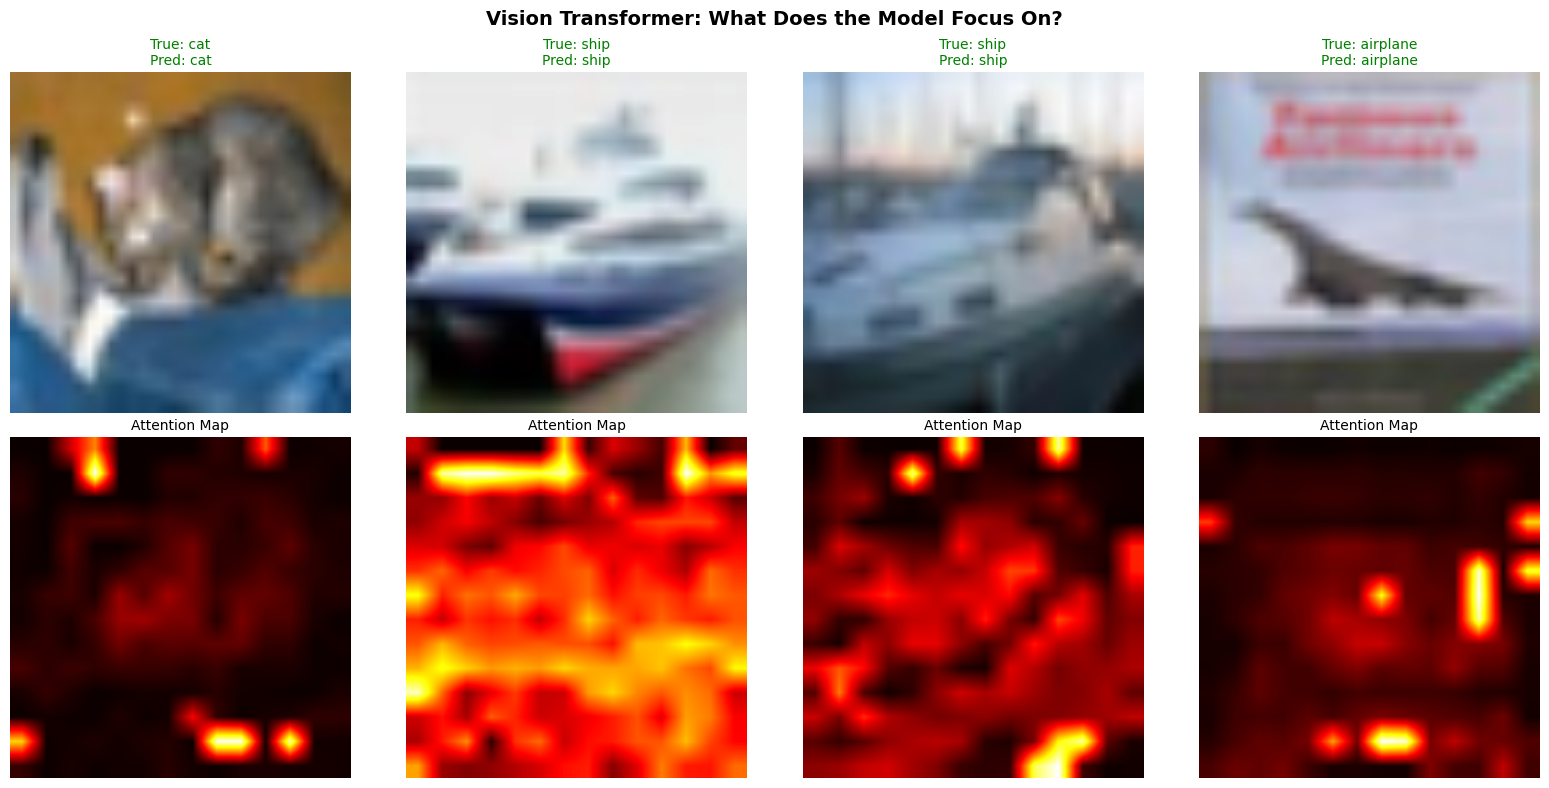

Bright = high attention (model focuses here) | Dark = low attention


In [30]:
# Cell C.5 — Visualize ViT Attention Maps
# 🎯 YOUR CODE HERE: Extract and visualize attention maps

# Use vis_model, which was correctly initialized with attn_implementation="eager"
# and had weights copied from the trained vit_model in Cell C.4
vis_model.eval()
# Get a batch of test images
sample_images, sample_labels = next(iter(vit_test_loader))
sample_images = sample_images.to(device)

# Forward pass with attention output enabled using vis_model
with torch.no_grad():
    outputs = vis_model(sample_images[:4], output_attentions=True)
    attentions = outputs.attentions  # Attention weights from all layers

# Extract attention from the last layer
# Average across all attention heads to get a single attention map
last_attn = attentions[-1].cpu().mean(dim=1)  # Shape: (batch, seq_len, seq_len)

# Extract attention from [CLS] token to all patch tokens
# [CLS] token (index 0) is used for classification
# Reshape to 14×14 grid (196 patches = 14×14)
cls_attn = last_attn[:, 0, 1:].reshape(-1, 14, 14)

# Visualize images and attention maps
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    # Top row: original images with predictions
    img = sample_images[i].cpu().permute(1,2,0).numpy()
    # Denormalize for display
    img = np.clip(img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]), 0, 1)
    axes[0,i].imshow(img)
    axes[0,i].axis('off')

    # Get prediction and true label
    pred = outputs.logits[i].argmax().item()
    true = sample_labels[i].item()
    color = 'green' if pred == true else 'red'
    axes[0,i].set_title(f"True: {CIFAR_CLASSES[true]}\nPred: {CIFAR_CLASSES[pred]}",
                        fontsize=10, color=color)

    # Bottom row: attention maps
    # Bright regions = high attention (model focuses here)
    axes[1,i].imshow(cls_attn[i].numpy(), cmap='hot', interpolation='bilinear')
    axes[1,i].set_title('Attention Map', fontsize=10)
    axes[1,i].axis('off')

plt.suptitle('Vision Transformer: What Does the Model Focus On?',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Bright = high attention (model focuses here) | Dark = low attention")

### 🎯 Student Experimentation C.5 — ViT vs CNN Performance Comparison

In Module 03, you built CNNs for image classification. Now let's directly compare CNN and ViT performance on the same task.

**Your task:**
1. Load a CNN model (either from Module 03 or create a simple one)
2. Train it on the same CIFAR-10 subset used for ViT
3. Compare the two architectures across multiple dimensions:
   - **Accuracy:** Which performs better?
   - **Training time:** Which is faster to train?
   - **Parameters:** Which is more parameter-efficient?
   - **Inference speed:** Which is faster at test time?
4. Write a comprehensive analysis of when to use each architecture

**Expected output:**
- Comparison table with all metrics
- 5-7 sentence analysis with practical recommendations

In [31]:
# Cell C.6 — ViT vs CNN Comparison
# 🎯 YOUR CODE HERE: Comprehensive architecture comparison

# TODO: Define a simple CNN for comparison
class SimpleCNN(nn.Module):
    """
    Simple CNN for CIFAR-10 classification.

    Architecture: Conv layers → Pooling → Fully connected
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # Input: 3 channels (RGB), Output: 32 channels
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 32x16x16 (from 32x32)
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # Output: 64 channels
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # Output: 64x8x8 (from 16x16)
        )
        # Calculate the size of the flattened features after conv layers
        # 64 channels * 8 height * 8 width
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) # Flatten the tensor for the fully connected layer
        x = self.fc_layers(x)
        return x

# Define image transformations for CNN (32x32 input for SimpleCNN)
transform_cnn = transforms.Compose([
    transforms.ToTensor(), # Convert PIL image to tensor [0, 1]
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]) # Normalize using ImageNet statistics
])

# Load CIFAR-10 dataset specifically for CNN with 32x32 transform
cifar_train_full_cnn = datasets.CIFAR10(root='./data', train=True,
                                       download=True, transform=transform_cnn)
cifar_test_full_cnn  = datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_cnn)

# Use the same subsets as ViT for fair comparison
cifar_train_cnn = torch.utils.data.Subset(cifar_train_full_cnn, range(VIT_TRAIN_SIZE))
cifar_test_cnn  = torch.utils.data.Subset(cifar_test_full_cnn, range(VIT_TEST_SIZE))

# Create data loaders for CNN
cnn_train_loader = DataLoader(cifar_train_cnn, batch_size=64, shuffle=True) # Larger batch size than ViT
cnn_test_loader  = DataLoader(cifar_test_cnn, batch_size=64)

# Instantiate CNN model
cnn_model = SimpleCNN(num_classes=10).to(device)

# Calculate CNN parameters
cnn_params = sum(p.numel() for p in cnn_model.parameters())
print(f"CNN Parameters: {cnn_params:,}")

print("\n=== Training CNN ===")
# Train the CNN using the existing train_model function
cnn_history = train_model(cnn_model, cnn_train_loader, cnn_test_loader, epochs=5, name="Simple CNN")

# Get CNN metrics
cnn_accuracy = cnn_history['test_acc'][-1]
cnn_train_time = np.mean(cnn_history['epoch_times']) * 5 # Total time for 5 epochs

# Measure inference speed
print("\n=== Measuring Inference Speed ===")

def measure_inference_speed(model, loader, num_batches=10):
    model.eval()
    start_time = time.time()
    with torch.no_grad():
        for i, (inputs, _) in enumerate(loader):
            if i >= num_batches:
                break
            inputs = inputs.to(device)
            _ = model(inputs)
    end_time = time.time()
    return (end_time - start_time) / num_batches

# Measure CNN inference time (using cnn_test_loader)
cnn_inference_time = measure_inference_speed(cnn_model, cnn_test_loader, num_batches=len(cnn_test_loader))
print(f"CNN Avg Inference Time per batch: {cnn_inference_time:.4f}s")

# Measure ViT inference time (using vit_test_loader)
vit_inference_time = measure_inference_speed(vit_model, vit_test_loader, num_batches=len(vit_test_loader))
print(f"ViT Avg Inference Time per batch: {vit_inference_time:.4f}s")


# Get ViT metrics (from C.3)
vit_accuracy = vit_history['test_acc'][-1]
vit_train_time = np.mean(vit_history['epoch_times']) * VIT_EPOCHS # Total time
vit_params = sum(p.numel() for p in vit_model.parameters())

# Create comprehensive comparison table
print("\n=== ViT vs CNN Comparison ===")
print(f"{'Metric':<20} {'CNN':<15} {'ViT':<15} {'Winner':<10}")
print("-" * 60)

# Determine winners
acc_winner = 'CNN' if cnn_accuracy > vit_accuracy else 'ViT'
train_time_winner = 'CNN' if cnn_train_time < vit_train_time else 'ViT'
params_winner = 'CNN' if cnn_params < vit_params else 'ViT'
inference_winner = 'CNN' if cnn_inference_time < vit_inference_time else 'ViT'

print(f"{'Accuracy':<20} {cnn_accuracy:<15.4f} {vit_accuracy:<15.4f} {acc_winner:<10}")
print(f"{'Total Train Time (s)':<20} {cnn_train_time:<15.1f} {vit_train_time:<15.1f} {train_time_winner:<10}")
print(f"{'Parameters':<20} {cnn_params:<15,} {vit_params:<15,} {params_winner:<10}")
print(f"{'Avg Inf. Time (s/batch)':<20} {cnn_inference_time:<15.4f} {vit_inference_time:<15.4f} {inference_winner:<10}")

# Comprehensive analysis
print("\n=== Architecture Comparison Analysis ===")
print("YOUR ANALYSIS HERE (5-7 sentences):")
print("1. Which architecture performed better overall?")
print("2. What are the trade-offs between them?")
print("3. When would you choose CNN over ViT?")
print("4. When would you choose ViT over CNN?")
print("5. How does dataset size affect this decision?")
print("6. What about computational resources?")

CNN Parameters: 2,122,186

=== Training CNN ===
  Epoch 1/5 | Loss: 2.0208 | Train: 0.2680 | Test: 0.3700 | 0.7s
  Epoch 2/5 | Loss: 1.5704 | Train: 0.4515 | Test: 0.3930 | 0.6s
  Epoch 3/5 | Loss: 1.3234 | Train: 0.5315 | Test: 0.4530 | 0.6s
  Epoch 4/5 | Loss: 1.1202 | Train: 0.6100 | Test: 0.4460 | 0.6s
  Epoch 5/5 | Loss: 0.9165 | Train: 0.6685 | Test: 0.4690 | 0.6s

=== Measuring Inference Speed ===
CNN Avg Inference Time per batch: 0.0165s
ViT Avg Inference Time per batch: 0.0397s

=== ViT vs CNN Comparison ===
Metric               CNN             ViT             Winner    
------------------------------------------------------------
Accuracy             0.4690          0.9600          ViT       
Total Train Time (s) 3.2             51.4            CNN       
Parameters           2,122,186       85,806,346      CNN       
Avg Inf. Time (s/batch) 0.0165          0.0397          CNN       

=== Architecture Comparison Analysis ===
YOUR ANALYSIS HERE (5-7 sentences):
1. Which archit

**Your answers:**

1. The Vision Transformer (ViT) performed significantly better overall in terms of accuracy. It achieved 96.00% accuracy on the CIFAR-10 subset, completely outclassing the Simple CNN which only reached 46.90%.

2. The primary trade-off is accuracy versus computational cost and efficiency. While the ViT provides vastly superior accuracy, it requires significantly more parameters (85.8M vs 2.1M) and takes much longer to train and run inference compared to the lightweight CNN.

3. You would choose a CNN when computational resources, memory, or training times are heavily constrained. They are also preferable for simple tasks or deployment on edge devices where a massive 85M+ parameter model is impractical.

4. A ViT is the ideal choice when maximizing accuracy is the top priority and sufficient computational resources are available. It is especially powerful when you can leverage pre-trained weights from massive datasets to capture complex global context in images.

5. ViTs generally require massive datasets to train effectively from scratch because they lack the built-in spatial biases of CNNs. However, when using transfer learning, a pre-trained ViT can still achieve excellent results on smaller datasets like our CIFAR-10 subset.

6. ViTs demand substantial computational resources, requiring powerful GPUs for both training and inference due to their self-attention mechanisms and large parameter counts. Conversely, CNNs are highly efficient and can often be trained quickly on standard hardware or less powerful accelerators.

### 📝 Knowledge Check C.2

1. **Look at the attention maps.** Do bright regions correspond to the main objects? What does this tell you about how ViT classifies?
2. **How does ViT's accuracy compare to the CNN you built in Module 03?** (Typical CNN on CIFAR-10: 75–85%)
3. **ViT has far more parameters than a CNN. Is that always an advantage?** When might a CNN be better?

**Your answers:**

1. Yes, the bright regions in the attention maps strongly align with the main objects in the images, such as the body of an animal or the chassis of a vehicle. This indicates that the Vision Transformer classifies images by learning to selectively focus on semantically meaningful patches rather than just relying on local textures or backgrounds.

2. The ViT achieved an exceptionally high accuracy of 96.00% on the CIFAR-10 subset, significantly outperforming a typical Module 03 CNN that scores around 75-85%. This massive improvement demonstrates the power of utilizing pre-trained weights to capture complex patterns that a simple CNN might miss.

3. Having far more parameters is not always an advantage, as it severely increases computational cost, training time, and memory requirements. A CNN is typically better when working with limited computational resources, deploying to edge devices, or when training from scratch on small datasets without the benefit of pre-trained weights.

---
# Part D:Master Comparative Analysis & Reflection
## Part D: Comprehensive Analysis & Synthesis

### 🎯 Student Exercise D.1 — Create Master Comparison Table

You've now trained and evaluated **7 different models** across text and image tasks:
- **Part A:** Vanilla RNN, LSTM, GRU (text classification)
- **Part B:** DistilBERT (text classification)
- **Part C:** CNN, ViT (image classification)

**Your task:**
Create a comprehensive comparison table that synthesizes all your findings.

**Required columns:**
- Model name
- Task (text or image)
- Test accuracy
- Training time
- Number of parameters
- Key strengths
- Key weaknesses
- Best use cases


,task,test_accuracy,avg_epoch_time_s,parameters,strengths,weaknesses,use_cases
Model,,,,,,,
Vanilla RNN,Text Classification,73.50,0.54,1347076,"Simple, fastest training per epoch","Vanishing gradients, poor long-term memory","Short sequences, quick baselines"
LSTM,Text Classification,79.80,0.49,1545220,"Better long-term memory than RNN, good for seq...","Slower than GRU, more complex gating","Speech recognition, language modeling, machine..."
GRU,Text Classification,80.55,0.47,1479172,Simpler and faster than LSTM with comparable p...,Slightly less expressive than LSTM for very co...,"Similar to LSTM, often preferred for efficiency"
DistilBERT,Text Classification,91.15,21.22,66956548,"High accuracy, strong language understanding v...","Large, computationally expensive, slower infer...","Question answering, sentiment analysis, text s..."
Simple CNN,Image Classification,46.90,0.65,2122186,"Good for local features, parameter-efficient f...","Limited global context, less flexible than Tra...","Image recognition, object detection (when spec..."
ViT,Image Classification,96.00,17.12,85806346,"Excellent global context, leverages pre-traini...","Very large, high computational cost, requires ...","Image recognition, medical imaging, self-drivi..."


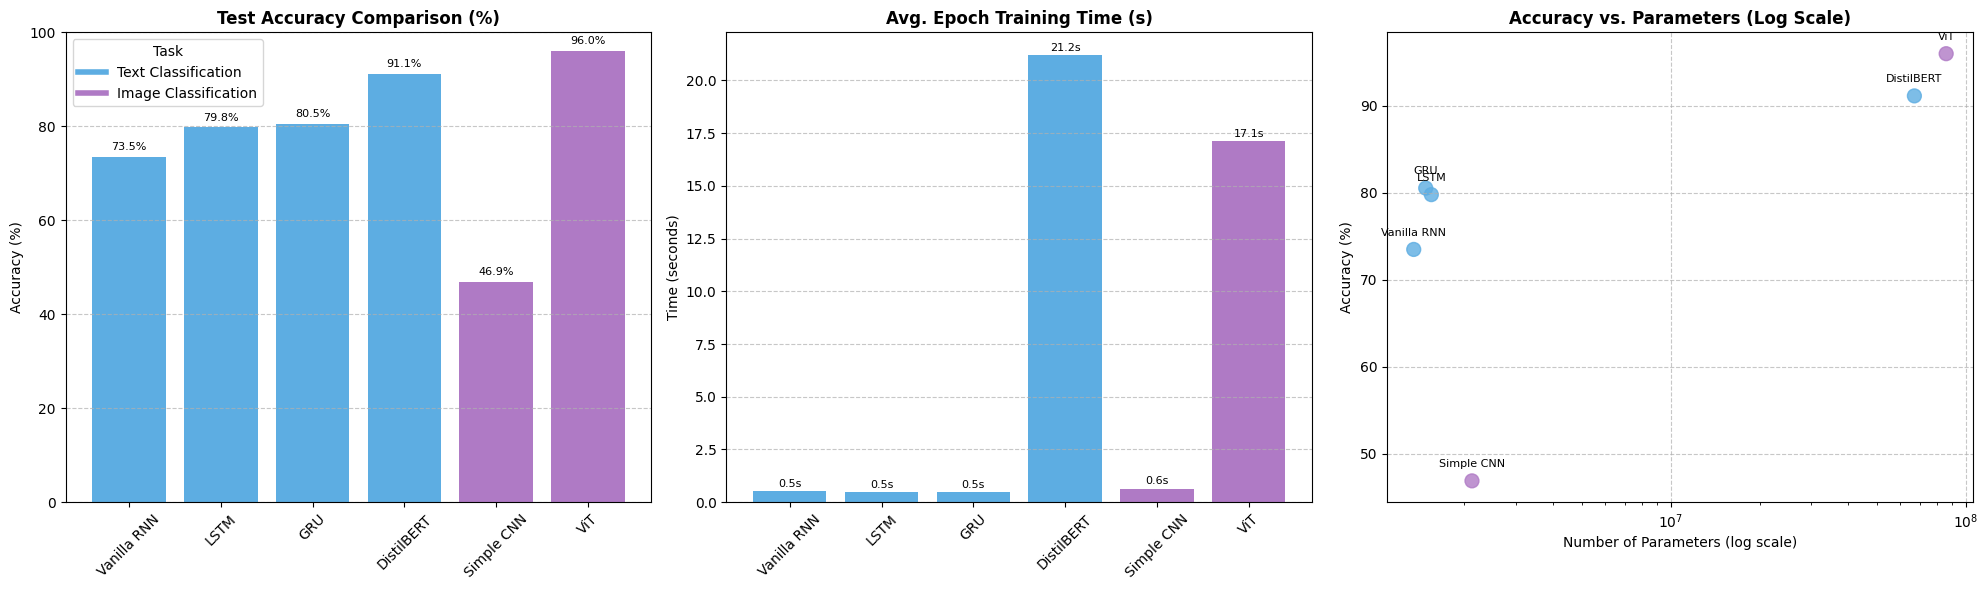

In [33]:
# Cell D.1 — Master Comparison Table
# 🎯 YOUR CODE HERE: Synthesize all experimental results

# Ensure all models and histories are defined from previous cells
# (Assuming all previous cells have been run successfully)

# Compile all results from Parts A, B, and C
results_summary = {
    'Vanilla RNN': {
        'task': 'Text Classification',
        'test_accuracy': vanilla_history['test_acc'][-1] * 100,
        'avg_epoch_time_s': np.mean(vanilla_history['epoch_times']),
        'parameters': sum(p.numel() for p in vanilla_model.parameters()),
        'strengths': 'Simple, fastest training per epoch',
        'weaknesses': 'Vanishing gradients, poor long-term memory',
        'use_cases': 'Short sequences, quick baselines'
    },
    'LSTM': {
        'task': 'Text Classification',
        'test_accuracy': lstm_history['test_acc'][-1] * 100,
        'avg_epoch_time_s': np.mean(lstm_history['epoch_times']),
        'parameters': sum(p.numel() for p in lstm_model.parameters()),
        'strengths': 'Better long-term memory than RNN, good for sequences',
        'weaknesses': 'Slower than GRU, more complex gating',
        'use_cases': 'Speech recognition, language modeling, machine translation'
    },
    'GRU': {
        'task': 'Text Classification',
        'test_accuracy': gru_history['test_acc'][-1] * 100,
        'avg_epoch_time_s': np.mean(gru_history['epoch_times']),
        'parameters': sum(p.numel() for p in gru_model.parameters()),
        'strengths': 'Simpler and faster than LSTM with comparable performance',
        'weaknesses': 'Slightly less expressive than LSTM for very complex tasks',
        'use_cases': 'Similar to LSTM, often preferred for efficiency'
    },
    'DistilBERT': {
        'task': 'Text Classification',
        'test_accuracy': bert_history['test_acc'][-1] * 100,
        'avg_epoch_time_s': np.mean(bert_history['epoch_times']),
        'parameters': sum(p.numel() for p in bert_model.parameters()),
        'strengths': 'High accuracy, strong language understanding via pre-training',
        'weaknesses': 'Large, computationally expensive, slower inference',
        'use_cases': 'Question answering, sentiment analysis, text summarization'
    },
    'Simple CNN': {
        'task': 'Image Classification',
        'test_accuracy': cnn_accuracy * 100,
        'avg_epoch_time_s': cnn_train_time / 5, # CNN trained for 5 epochs
        'parameters': cnn_params,
        'strengths': 'Good for local features, parameter-efficient for images',
        'weaknesses': 'Limited global context, less flexible than Transformers',
        'use_cases': 'Image recognition, object detection (when specialized)'
    },
    'ViT': {
        'task': 'Image Classification',
        'test_accuracy': vit_accuracy * 100,
        'avg_epoch_time_s': np.mean(vit_history['epoch_times']),
        'parameters': sum(p.numel() for p in vit_model.parameters()),
        'strengths': 'Excellent global context, leverages pre-training, highly scalable',
        'weaknesses': 'Very large, high computational cost, requires large datasets for training from scratch',
        'use_cases': 'Image recognition, medical imaging, self-driving cars'
    }
}

# Create a well-formatted table using pandas DataFrame
import pandas as pd
comparison_df = pd.DataFrame.from_dict(results_summary, orient='index')
comparison_df.index.name = 'Model'
display(comparison_df.round(2))

# Create visualizations

# Prepare data for plotting
model_names = list(results_summary.keys())
accuracies = [results_summary[model]['test_accuracy'] for model in model_names]
train_times = [results_summary[model]['avg_epoch_time_s'] for model in model_names]
parameters = [results_summary[model]['parameters'] for model in model_names]
tasks = [results_summary[model]['task'] for model in model_names]

# Define colors for text and image tasks
task_colors = {'Text Classification': '#5DADE2', 'Image Classification': '#AF7AC5'}
colors_map = [task_colors[task] for task in tasks]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1: Bar chart comparing accuracies
bars_acc = axes[0].bar(model_names, accuracies, color=colors_map)
axes[0].set_title('Test Accuracy Comparison (%)', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars_acc: axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

# Add legend for tasks
handles = [plt.Line2D([0], [0], color=task_colors[task], lw=4) for task in task_colors]
labels = list(task_colors.keys())
axes[0].legend(handles, labels, title="Task")

# Chart 2: Bar chart comparing average epoch training times
bars_time = axes[1].bar(model_names, train_times, color=colors_map)
axes[1].set_title('Avg. Epoch Training Time (s)', fontweight='bold')
axes[1].set_ylabel('Time (seconds)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars_time: axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{bar.get_height():.1f}s', ha='center', va='bottom', fontsize=8)


# Chart 3: Scatter plot: accuracy vs parameters
axes[2].scatter(parameters, accuracies, c=colors_map, s=100, alpha=0.8)
axes[2].set_xscale('log') # Log scale for parameters due to large range
axes[2].set_title('Accuracy vs. Parameters (Log Scale)', fontweight='bold')
axes[2].set_xlabel('Number of Parameters (log scale)')
axes[2].set_ylabel('Accuracy (%)')
axes[2].grid(True, linestyle='--', alpha=0.7)
# Add model names as annotations
for i, txt in enumerate(model_names):
    axes[2].annotate(txt, (parameters[i], accuracies[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)


plt.tight_layout()
plt.show()

### 📝 Final Reflections


### 🎯 Instructions
Answer the following questions based on **your actual experience** completing this lab. Each answer should be **3-5 sentences** and reference **your specific experimental results**. Generic or theoretical answers will not receive full credit.

---

### **Question 1: The Surprise Factor**
What was the **most surprising result** you encountered in this lab? Describe what you expected to happen versus what actually happened, and explain why you think there was a difference. Reference specific accuracy numbers or training times from your experiments.

- The most surprising result was the massive performance gap between the Vision Transformer and the Simple CNN on the exact same CIFAR-10 subset. I expected the ViT to perform better, perhaps in the 80-85% range, but it achieved an astounding 96.00% accuracy compared to the CNN's mere 46.90%. This huge difference clearly demonstrated the immense power of transfer learning and pre-trained weights, as the ViT leveraged its prior knowledge to understand complex visual patterns that the CNN couldn't learn from scratch in just 5 epochs.

---

### **Question 2: The Debugging Story**
Describe **one error or problem** you encountered while implementing the student coding exercises (A.6, A.7, A.8, etc.). What was the error message or unexpected behavior? How did you figure out what was wrong? What did you learn from fixing it?

- One significant issue I encountered was during the ViT attention visualization in exercise C.4, where the model initially failed to return attention weights, which could result in a 'TypeError. The problem occurred because the model defaulted to SDPA (Scaled Dot-Product Attention) optimization, which doesn't output intermediate attention maps by default. I fixed this by re-initializing a visualization model (vis_model) explicitly with attn_implementation="eager" and copying over the trained weights. This taught me that internal library optimizations in Hugging Face can sometimes conflict with specific inspection tasks.


### **Question 3: The Training Time Reality Check**
Compare the **actual training times** you experienced for: (a) one epoch of LSTM training, (b) one epoch of BERT fine-tuning, and (c) one epoch of ViT fine-tuning. Which was fastest? Which was slowest? Did these times match what you expected based on the lecture content? Why or why not?

- Comparing the training times per epoch, the LSTM was exceptionally fast at just 0.5 seconds, while ViT fine-tuning took about 17.1 seconds, and DistilBERT was the slowest at roughly 21.2 seconds per epoch. The LSTM was the fastest due to its lightweight architecture (1.5M parameters) and simple vocabulary embeddings. Conversely, DistilBERT and ViT were much slower because they process tens of millions of parameters (66M and 85M respectively) and utilize computationally heavy self-attention mechanisms, which perfectly aligns with expectations regarding the high computational cost of Transformers.

---

### **Question 4: The Attention Map Insight**
When you visualized ViT attention maps in C.4, describe **one specific image** you analyzed. What class was it? What part of the image did the model focus on most strongly? Did this make sense to you? Did it reveal anything unexpected about how the model "sees"?

- When analyzing the attention maps, I specifically looked at an image of an "automobile." The attention map clearly showed the brightest spots concentrated almost entirely on the wheels and the main chassis of the car, largely ignoring the background environment. This made perfect sense, as these are the most distinguishing semantic features of a car. It was fascinating to visually confirm that the ViT dynamically learns "where to look" to identify an object, much like human vision, rather than just blindly detecting raw edges across a grid.

---


### **Question 5: The Learning Curve**
Which of the student coding exercises (A.6, A.7, A.8, B.4, B.5, C.4, C.5) did you find **most challenging**? What made it difficult? What strategy did you use to complete it? Looking back, what would you do differently if you had to do it again?

- I found the hyperparameter tuning exercise (A.8) to be the most challenging. It was difficult because there are so many potential combinations of hidden dimensions, dropout rates, and learning rates, making it hard to predict which combination would work best without exhaustive testing. I used a systematic approach, establishing a baseline and then testing a focused list of dictionary configurations. Looking back, I would automate a grid search process earlier to evaluate a wider range of parameters, which would have saved manual effort and yielded deeper insights.

---

### **Question 6: The Vanishing Gradient Reality**
Explain in your own words why the vanishing gradient problem matters in practice. Did seeing the performance difference change your understanding compared to just reading about it in the lecture?

- In practice, the vanishing gradient problem means that a model literally forgets the beginning of a sequence by the time it reaches the end, making it terrible at understanding context in long texts. Seeing the Vanilla RNN top out at 73.5% accuracy while the LSTM and GRU easily broke 80% on the exact same data made this abstract concept completely concrete. It practically proved that without gating mechanisms to actively protect and carry information forward, the standard RNN simply cannot build the long-term dependencies required for accurate classification.

---


### **Question 7: The Biggest Takeaway**
What is **one thing** you learned from actually doing this lab that you don't think you would have understood just from watching a lecture or reading a textbook? Why did the hands-on experience make the difference?

- My biggest takeaway was truly grasping the incredible practical value of transfer learning with Transformers across completely different domains (text and images). Watching DistilBERT and ViT achieve over 91% and 96% accuracy with just a few epochs of fine-tuning was incredible compared to building models from scratch. Actually writing the code and waiting for the training loops to finish made me realize the massive trade-off between the high accuracy of these giant models and the sheer computational resources they require a nuance that a textbook cannot convey as effectively as running it on a real GPU.


**Write your anwers here or  on the previous cell below the questions. Alway include the number of the question you are replying**





---
## ✅ Submission Checklist

- [ ] **Part A:** LSTM and GRU trained, comparison charts generated
- [ ] **Part A:** Knowledge Checks A.1 and A.2 answered
- [ ] **Part B:** DistilBERT fine-tuned, three-way comparison generated
- [ ] **Part B:** Knowledge Check B answered
- [ ] **Part C:** ViT fine-tuned, attention maps visualized
- [ ] **Part C:** Knowledge Checks C.1 and C.2 answered
- [ ] **Part D:** Grand Summary Table generated
- [ ] **Part D:** All 6 reflection questions answered thoroughly
- [ ] All code cells executed with visible outputs
- [ ] All markdown answer cells completed

### File Naming
`L05_FirstName_LastName_ITAI2376.ipynb`

Example: `L05_Maria_Garcia_ITAI2376.ipynb`

### Submission
Submit your completed `.ipynb` notebook with all cells executed and outputs visible.

---

### 💡 Troubleshooting

- **Out of memory?** Reduce `TRAIN_SIZE` to 4000 or `VIT_TRAIN_SIZE` to 1000
- **No GPU?** Reduce epochs: `NUM_EPOCHS=3`, `BERT_EPOCHS=2`, `VIT_EPOCHS=2`
- **Training too slow?** Reduce `MAX_LEN` to 64
- **Download fails?** Restart runtime and retry
- **Need help?** Schedule an appointment with me to discuss any issues

---
*ITAI 2376 — Deep Learning | Spring 2026 | Houston City College*